# REPORT: Data Understanding and Exploratory Data Analysis
## Project: Forecast Restaurant Visitors with Time Series Analysis

## 1. Problem Introduction

The goal is to forecast future restaurant visitors using historical visits, reservations, calendar effects, and store metadata.

This notebook focuses on understanding the raw data, checking its structure and quality, and identifying patterns that motivate the final forecasting approach.


---
## 2. Environment Setup
### 2.1 Load Libraries

This section loads the Python libraries used for data analysis, time series exploration, and visualization.


In [1]:
# This notebook assumes the environment has already been prepared
# with `pip install -r requirements.txt`.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_squared_error, mean_absolute_error

import plotly.express as px

import folium
from geopy.distance import geodesic

pd.options.mode.chained_assignment = None

print("All libraries loaded successfully.")


In [2]:

import math

def multiplot(plots, cols=1, figsize=(10, 6)):
    """
    plots: list các hàm plot (hoặc callable vẽ lên ax)
    cols: số cột
    figsize: kích thước figure
    """
    num_plots = len(plots)
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], figsize[1]*rows))

    # Nếu chỉ có 1 plot
    if num_plots == 1:
        axes = [axes]

    # Flatten axes để dễ loop
    if isinstance(axes, (list, tuple)):
        axes_flat = axes
    else:
        axes_flat = axes.flatten()

    for i, plot_func in enumerate(plots):
        plot_func(axes_flat[i])  # gọi hàm vẽ

    # Ẩn các subplot dư
    for j in range(num_plots, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

### 2.2 Load the Data

All CSV files are loaded directly from the working directory so we can inspect their size and overall structure before cleaning or modeling.


In [3]:

import os

# ==============================
# 1. Đường dẫn
# ==============================
from pathlib import Path
BASE_DIR = Path.cwd()
NOTEBOOK_DIR = BASE_DIR if (BASE_DIR / 'raw_Data').exists() else BASE_DIR / 'notebooks'
rpath = str(NOTEBOOK_DIR / 'raw_Data') + '/'

# ==============================
# 2. Load dữ liệu
# ==============================
air_visits  = pd.read_csv(os.path.join(rpath, "air_visit_data.csv"))
air_reserve = pd.read_csv(os.path.join(rpath, "air_reserve.csv"))
hpg_reserve = pd.read_csv(os.path.join(rpath, "hpg_reserve.csv"))
air_store   = pd.read_csv(os.path.join(rpath, "air_store_info.csv"))
hpg_store   = pd.read_csv(os.path.join(rpath, "hpg_store_info.csv"))
holidays    = pd.read_csv(os.path.join(rpath, "date_info.csv"))
store_ids   = pd.read_csv(os.path.join(rpath, "store_id_relation.csv"))
test        = pd.read_csv(os.path.join(rpath, "sample_submission.csv"))

# ==============================
# 3. In thông tin
# ==============================
datasets = {
    "air_visits": air_visits,
    "air_reserve": air_reserve,
    "hpg_reserve": hpg_reserve,
    "air_store": air_store,
    "hpg_store": hpg_store,
    "holidays": holidays,
    "store_ids": store_ids,
    "test": test
}

print("File                   Rows      Cols")
print("---------------------------------------")

for name, df in datasets.items():
    print(f"{name:<22} {df.shape[0]:7d}   {df.shape[1]:4d}")

File                   Rows      Cols
---------------------------------------
air_visits              252108      3
air_reserve              92378      4
hpg_reserve            2000320      4
air_store                  829      5
hpg_store                 4690      5
holidays                   517      3
store_ids                  150      2
test                     32019      2


**Notes on dataset size:**
- `air_visit_data` is the main training set.
- `hpg_reserve` is much larger than `air_reserve`.
- `store_id_relation` links only a limited subset of AIR and HPG stores.
- The project therefore needs careful handling when combining reservation sources.


---
## 3. Data Overview
### 3.1 `air_visit_data`: Main Training Table

Each row records the number of visitors for one AIR restaurant on one date. This is the target series used for forecasting.


In [4]:


# ==============================
# 1. CẤU TRÚC DỮ LIỆU
# ==============================
print("=== CẤU TRÚC DỮ LIỆU ===")
print(air_visits.info())

# ==============================
# 2. THỐNG KÊ MÔ TẢ
# ==============================
print("\n=== THỐNG KÊ MÔ TẢ ===")
print(air_visits.describe(include='all'))

# ==============================
# 3. THÔNG TIN BỔ SUNG
# ==============================

# Convert sang datetime (giống ymd trong R)
air_visits["visit_date"] = pd.to_datetime(air_visits["visit_date"])

print("\n=== THÔNG TIN BỔ SUNG ===")

print("Số nhà hàng AIR duy nhất  :", air_visits["air_store_id"].nunique())
print("Số ngày có dữ liệu        :", air_visits["visit_date"].nunique())
print("Ngày bắt đầu              :", air_visits["visit_date"].min().date())
print("Ngày kết thúc             :", air_visits["visit_date"].max().date())
print("Tổng số bản ghi           :", len(air_visits))
print("Số khách TB/ngày/nhà hàng :", round(air_visits["visitors"].mean(), 2))
print("Số khách Max              :", air_visits["visitors"].max())

=== CẤU TRÚC DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252108 entries, 0 to 252107
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   air_store_id  252108 non-null  object
 1   visit_date    252108 non-null  object
 2   visitors      252108 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 5.8+ MB
None

=== THỐNG KÊ MÔ TẢ ===
                air_store_id  visit_date       visitors
count                 252108      252108  252108.000000
unique                   829         478            NaN
top     air_5c817ef28f236bdf  2017-03-17            NaN
freq                     477         799            NaN
mean                     NaN         NaN      20.973761
std                      NaN         NaN      16.757007
min                      NaN         NaN       1.000000
25%                      NaN         NaN       9.000000
50%                      NaN         NaN      17.000000
75%        

**Notes:**
- `air_visit_data` defines the store-level forecasting target.
- The number of stores is small enough to support store-level modeling.
- Visitor counts vary substantially across stores, which suggests strong heterogeneity.


In [5]:
# ==============================
# 1. CẤU TRÚC DỮ LIỆU
# ==============================
print("=== CẤU TRÚC air_reserve ===")
print(air_reserve.info())

# ==============================
# 2. THỐNG KÊ NHANH
# ==============================
print("\nSố nhà hàng AIR có đặt bàn    :", air_reserve["air_store_id"].nunique())
print("Tổng số đặt bàn (air)         :", len(air_reserve))
print("Số khách đặt TB/lần           :", round(air_reserve["reserve_visitors"].mean(), 2))

=== CẤU TRÚC air_reserve ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92378 entries, 0 to 92377
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   air_store_id      92378 non-null  object
 1   visit_datetime    92378 non-null  object
 2   reserve_datetime  92378 non-null  object
 3   reserve_visitors  92378 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.8+ MB
None

Số nhà hàng AIR có đặt bàn    : 314
Tổng số đặt bàn (air)         : 92378
Số khách đặt TB/lần           : 4.48


**Notes:**
- Only part of the AIR stores have reservation data.
- Reservation timestamps provide lead-time information.
- Reservation data is useful, but it does not fully cover all stores or all dates.


In [6]:
# ==============================
# 1. CẤU TRÚC DỮ LIỆU
# ==============================
print("=== CẤU TRÚC hpg_reserve ===")
print(hpg_reserve.info())

# ==============================
# 2. THỐNG KÊ NHANH
# ==============================
print("\nSố nhà hàng HPG có đặt bàn    :", hpg_reserve["hpg_store_id"].nunique())
print("Tổng số đặt bàn (hpg)         :", len(hpg_reserve))
print("Số khách đặt TB/lần           :", round(hpg_reserve["reserve_visitors"].mean(), 2))

=== CẤU TRÚC hpg_reserve ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000320 entries, 0 to 2000319
Data columns (total 4 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   hpg_store_id      object
 1   visit_datetime    object
 2   reserve_datetime  object
 3   reserve_visitors  int64 
dtypes: int64(1), object(3)
memory usage: 61.0+ MB
None

Số nhà hàng HPG có đặt bàn    : 13325
Tổng số đặt bàn (hpg)         : 2000320
Số khách đặt TB/lần           : 5.07


**Notes:**
- HPG contains many more reservation records than AIR.
- Its structure is similar to AIR reservations, but uses `hpg_store_id`.
- HPG must be mapped to AIR through `store_id_relation` before use in the final model.


In [7]:
# ==============================
# 1. AIR STORE INFO
# ==============================
print("=== AIR STORE INFO ===")
print(air_store.info())

print("\nSố thể loại ẩm thực AIR:", air_store["air_genre_name"].nunique())
print("Số khu vực AIR         :", air_store["air_area_name"].nunique())

# ==============================
# 2. HPG STORE INFO
# ==============================
print("\n=== HPG STORE INFO ===")
print(hpg_store.info())

print("\nSố thể loại ẩm thực HPG:", hpg_store["hpg_genre_name"].nunique())
print("Số khu vực HPG         :", hpg_store["hpg_area_name"].nunique())

=== AIR STORE INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_store_id    829 non-null    object 
 1   air_genre_name  829 non-null    object 
 2   air_area_name   829 non-null    object 
 3   latitude        829 non-null    float64
 4   longitude       829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB
None

Số thể loại ẩm thực AIR: 14
Số khu vực AIR         : 103

=== HPG STORE INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hpg_store_id    4690 non-null   object 
 1   hpg_genre_name  4690 non-null   object 
 2   hpg_area_name   4690 non-null   object 
 3   latitude        4690 non-null   float64
 4   longitude       4690 non-null   float

**Notes:**
- Store metadata includes cuisine genre, geographic area, and approximate coordinates.
- Coordinates represent area centroids rather than precise restaurant addresses.
- These variables help explain store-level heterogeneity.


In [8]:
# ==============================
# 1. DATE INFO (HOLIDAYS)
# ==============================
print("=== DATE INFO (HOLIDAYS) ===")
print(holidays.info())

print("\nTổng số ngày trong file:", len(holidays))
print("Số ngày lễ            :", holidays["holiday_flg"].sum())
print("Tỷ lệ ngày lễ         :", round(holidays["holiday_flg"].mean() * 100, 1), "%")

# ==============================
# 2. STORE ID RELATION
# ==============================
print("\n=== STORE ID RELATION ===")
print(store_ids.info())

print("\nSố cặp AIR-HPG được liên kết:", len(store_ids))
print("Tỷ lệ nhà hàng AIR được liên kết:",
      round(len(store_ids) / len(air_store) * 100, 1), "%")

=== DATE INFO (HOLIDAYS) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   calendar_date  517 non-null    object
 1   day_of_week    517 non-null    object
 2   holiday_flg    517 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 12.2+ KB
None

Tổng số ngày trong file: 517
Số ngày lễ            : 35
Tỷ lệ ngày lễ         : 6.8 %

=== STORE ID RELATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   air_store_id  150 non-null    object
 1   hpg_store_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB
None

Số cặp AIR-HPG được liên kết: 150
Tỷ lệ nhà hàng AIR được liên kết: 18.1 %


**Notes:**
- `date_info` marks national holidays.
- Only a limited subset of AIR stores can be linked to HPG.
- Calendar effects are likely useful, but cross-platform reservation integration is partial.


In [9]:
# ==============================
# 1. HEADER
# ==============================
print("=== KIỂM TRA GIÁ TRỊ THIẾU ===")
print(f"{'File':<22}  {'Rows':>10}  {'Cols':>10}  {'Missing':>10}")
print("-" * 58)

# ==============================
# 2. DANH SÁCH DATASETS
# ==============================
datasets = {
    "air_visits": air_visits,
    "air_reserve": air_reserve,
    "hpg_reserve": hpg_reserve,
    "air_store": air_store,
    "hpg_store": hpg_store,
    "holidays": holidays,
    "store_ids": store_ids,
    "test": test
}

# ==============================
# 3. LOOP KIỂM TRA
# ==============================
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name:<22}  {df.shape[0]:10d}  {df.shape[1]:10d}  {missing:10d}")

# ==============================
# 4. KẾT LUẬN
# ==============================
print("\n→ KẾT LUẬN: Không có giá trị thiếu trong bất kỳ file nào.")

=== KIỂM TRA GIÁ TRỊ THIẾU ===
File                          Rows        Cols     Missing
----------------------------------------------------------
air_visits                  252108           3           0
air_reserve                  92378           4           0
hpg_reserve                2000320           4           0
air_store                      829           5           0
hpg_store                     4690           5           0
holidays                       517           3           0
store_ids                      150           2           0
test                         32019           2           0

→ KẾT LUẬN: Không có giá trị thiếu trong bất kỳ file nào.


**Notes:**
- The raw tables contain no explicit missing values.
- However, the data is still sparse in a time-series sense because many stores are absent on some dates.
- Sparse coverage must be handled carefully during feature engineering and evaluation.


In [10]:
import pandas as pd

# ==============================
# 1. AIR_VISITS
# ==============================
air_visits["visit_date"] = pd.to_datetime(air_visits["visit_date"])

# Tạo weekday (Mon → Sun)
air_visits["wday"] = air_visits["visit_date"].dt.day_name().str[:3]

# Sắp xếp thứ tự weekday giống R
wday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
air_visits["wday"] = pd.Categorical(air_visits["wday"], categories=wday_order, ordered=True)

# Tạo month
air_visits["month"] = air_visits["visit_date"].dt.month_name().str[:3]

# ==============================
# 2. RESERVATION FILES
# ==============================
air_reserve["visit_datetime"] = pd.to_datetime(air_reserve["visit_datetime"])
air_reserve["reserve_datetime"] = pd.to_datetime(air_reserve["reserve_datetime"])

hpg_reserve["visit_datetime"] = pd.to_datetime(hpg_reserve["visit_datetime"])
hpg_reserve["reserve_datetime"] = pd.to_datetime(hpg_reserve["reserve_datetime"])

# ==============================
# 3. STORE INFO (category = factor)
# ==============================
air_store["air_genre_name"] = air_store["air_genre_name"].astype("category")
air_store["air_area_name"]  = air_store["air_area_name"].astype("category")

hpg_store["hpg_genre_name"] = hpg_store["hpg_genre_name"].astype("category")
hpg_store["hpg_area_name"]  = hpg_store["hpg_area_name"].astype("category")

# ==============================
# 4. HOLIDAYS
# ==============================
holidays["holiday_flg"] = holidays["holiday_flg"].astype(bool)
holidays["date"] = pd.to_datetime(holidays["calendar_date"])
holidays["calendar_date"] = holidays["calendar_date"].astype(str)

# ==============================
# 5. THÔNG BÁO
# ==============================
print("✓ Chuyển đổi kiểu dữ liệu hoàn tất.")
print("  - visit_date: string → datetime")
print("  - reserve_datetime/visit_datetime: string → datetime")
print("  - genre_name/area_name: string → category")
print("  - holiday_flg: integer → boolean")
print("  - Thêm cột wday, month từ visit_date")

✓ Chuyển đổi kiểu dữ liệu hoàn tất.
  - visit_date: string → datetime
  - reserve_datetime/visit_datetime: string → datetime
  - genre_name/area_name: string → category
  - holiday_flg: integer → boolean
  - Thêm cột wday, month từ visit_date


**Notes:**
- Type conversion is necessary before analysis.
- Date variables allow weekday and month extraction.
- These derived fields are central for seasonality analysis.


In [11]:
# ==============================
# LOAD CLEANED DATA CHO EDA
# ==============================
import os, pandas as pd

from pathlib import Path
BASE_DIR = Path.cwd()
NOTEBOOK_DIR = BASE_DIR if (BASE_DIR / 'processed_data').exists() else BASE_DIR / 'notebooks'
ppath = str(NOTEBOOK_DIR / 'processed_data') + '/'

air_visits  = pd.read_csv(os.path.join(ppath, "air_visits.csv"),  parse_dates=["visit_date"])
air_reserve = pd.read_csv(os.path.join(ppath, "air_reserve.csv"), parse_dates=["visit_datetime", "reserve_datetime"])
hpg_reserve = pd.read_csv(os.path.join(ppath, "hpg_reserve.csv"), parse_dates=["visit_datetime", "reserve_datetime"])
air_store   = pd.read_csv(os.path.join(ppath, "air_store.csv"))
hpg_store   = pd.read_csv(os.path.join(ppath, "hpg_store.csv"))
holidays    = pd.read_csv(os.path.join(ppath, "holidays.csv"),    parse_dates=["date"])
store_ids   = pd.read_csv(os.path.join(ppath, "store_ids.csv"))

# Khoi phuc Categorical va Boolean (bi mat khi luu CSV)
wday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
air_visits["wday"] = pd.Categorical(air_visits["wday"], categories=wday_order, ordered=True)
air_store["air_genre_name"] = air_store["air_genre_name"].astype("category")
air_store["air_area_name"]  = air_store["air_area_name"].astype("category")
hpg_store["hpg_genre_name"] = hpg_store["hpg_genre_name"].astype("category")
hpg_store["hpg_area_name"]  = hpg_store["hpg_area_name"].astype("category")
holidays["holiday_flg"]   = holidays["holiday_flg"].astype(bool)
holidays["calendar_date"] = holidays["date"].dt.strftime("%Y-%m-%d")

print("Du lieu sach da load cho EDA:")
for name, df in [
    ("air_visits",  air_visits),  ("air_reserve", air_reserve),
    ("hpg_reserve", hpg_reserve), ("air_store",   air_store),
    ("hpg_store",   hpg_store),   ("holidays",    holidays),
    ("store_ids",   store_ids),
]:
    print(f"  {name:<15} {df.shape[0]:>8,} rows  {df.shape[1]:>2} cols")

Du lieu sach da load cho EDA:
  air_visits       251,220 rows   5 cols
  air_reserve       85,661 rows   4 cols
  hpg_reserve     1,980,105 rows   4 cols
  air_store            829 rows   5 cols
  hpg_store          4,690 rows   5 cols
  holidays             517 rows   4 cols
  store_ids            150 rows   2 cols


C:\Users\asus\AppData\Local\Temp\ipykernel_21244\1985238336.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_wday  = air_visits.groupby("wday")["visitors"].median().reset_index(name="med")


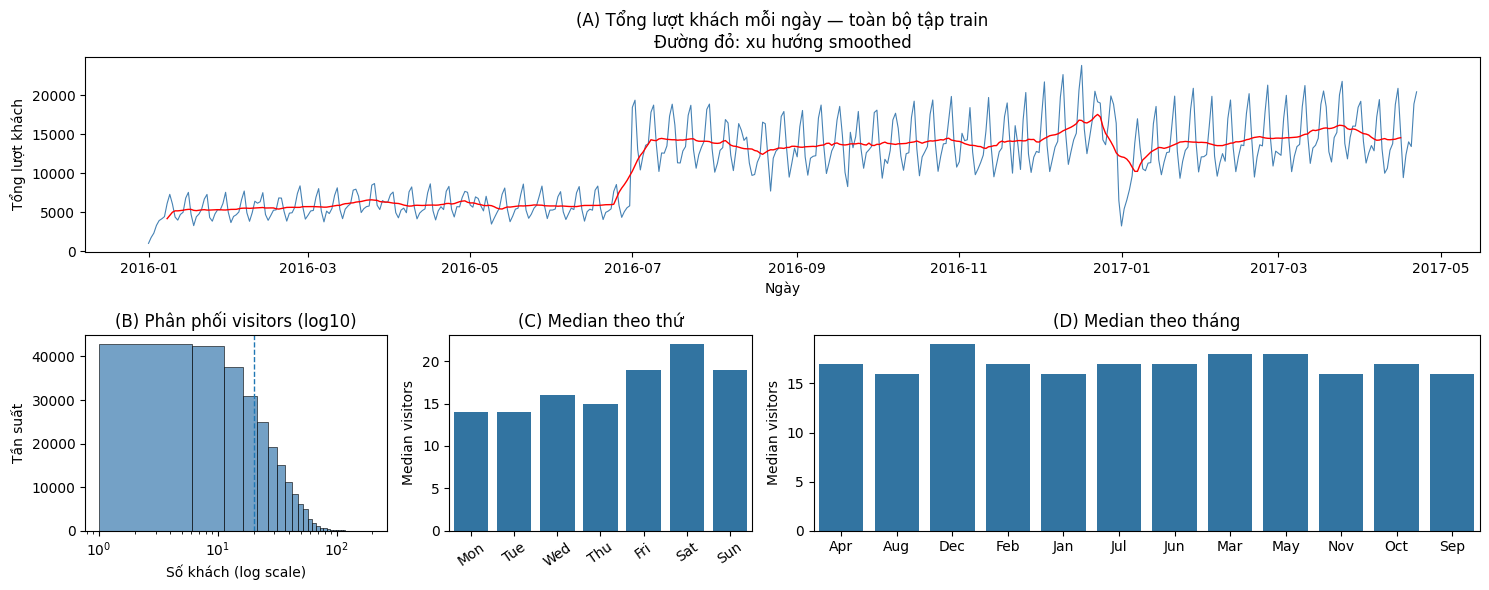

In [12]:


# ==============================
# 1. PREP DATA
# ==============================
df_daily = air_visits.groupby("visit_date")["visitors"].sum().reset_index()
df_wday  = air_visits.groupby("wday")["visitors"].median().reset_index(name="med")
df_month = air_visits.groupby("month")["visitors"].median().reset_index(name="med")

# ==============================
# 2. FIGURE LAYOUT (2x4 grid)
# ==============================
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(2, 4)

# ==============================
# (A) TIME SERIES
# ==============================
ax1 = fig.add_subplot(gs[0, :])  # chiếm full hàng trên

sns.lineplot(data=df_daily, x="visit_date", y="visitors",
             ax=ax1, color="steelblue", linewidth=0.8)

# Smooth line (approx LOESS bằng rolling mean)
df_daily["smooth"] = df_daily["visitors"].rolling(window=14, center=True).mean()
ax1.plot(df_daily["visit_date"], df_daily["smooth"], color="red", linewidth=1)

ax1.set_title("(A) Tổng lượt khách mỗi ngày — toàn bộ tập train\nĐường đỏ: xu hướng smoothed")
ax1.set_xlabel("Ngày")
ax1.set_ylabel("Tổng lượt khách")

# ==============================
# (B) HISTOGRAM (log scale)
# ==============================
ax2 = fig.add_subplot(gs[1, 0])

sns.histplot(air_visits["visitors"], bins=40, color="steelblue", ax=ax2)

ax2.axvline(20, linestyle="--", linewidth=1)
ax2.set_xscale("log")
ax2.set_title("(B) Phân phối visitors (log10)")
ax2.set_xlabel("Số khách (log scale)")
ax2.set_ylabel("Tần suất")

# ==============================
# (C) WEEKDAY MEDIAN
# ==============================
ax3 = fig.add_subplot(gs[1, 1])

sns.barplot(data=df_wday, x="wday", y="med", ax=ax3)
ax3.set_title("(C) Median theo thứ")
ax3.set_xlabel("")
ax3.set_ylabel("Median visitors")
ax3.tick_params(axis='x', rotation=35)

# ==============================
# (D) MONTH MEDIAN
# ==============================
ax4 = fig.add_subplot(gs[1, 2:4])  # chiếm 2 cột cuối

sns.barplot(data=df_month, x="month", y="med", ax=ax4)
ax4.set_title("(D) Median theo tháng")
ax4.set_xlabel("")
ax4.set_ylabel("Median visitors")

# ==============================
# FINALIZE
# ==============================
plt.tight_layout()
plt.show()

**Notes on the aggregate time series:**
- The total visitor series shows a step-like upward pattern over time.
- Weekly seasonality is visually strong.
- The series likely mixes genuine demand change with changes in store coverage.


### 4.2 Descriptive Statistics by Store


In [13]:
# ==============================
# 1. TÍNH THỐNG KÊ THEO STORE
# ==============================
store_stats = (
    air_visits
    .groupby("air_store_id")
    .agg(
        n_days=("visitors", "count"),
        mean_v=("visitors", "mean"),
        median_v=("visitors", "median"),
        sd_v=("visitors", "std"),
        max_v=("visitors", "max")
    )
    .reset_index()
)

# Coefficient of Variation (CV)
store_stats["cv"] = store_stats["sd_v"] / store_stats["mean_v"]

# ==============================
# 2. SUMMARY
# ==============================
print("=== THỐNG KÊ THEO TỪNG NHÀ HÀNG ===")
print(store_stats.drop(columns=["air_store_id"]).describe())

# ==============================
# 3. TOP 10 ĐÔNG KHÁCH NHẤT
# ==============================
print("\n=== TOP 10 ĐÔNG KHÁCH NHẤT ===")
top10_busy = (
    store_stats
    .sort_values(by="mean_v", ascending=False)
    .head(10)[["air_store_id", "mean_v", "median_v", "sd_v", "cv", "n_days"]]
)
print(top10_busy)

# ==============================
# 4. 10 NHÀ HÀNG ỔN ĐỊNH NHẤT (CV thấp)
# ==============================
print("\n=== 10 NHẤT QUÁN NHẤT (CV thấp nhất) ===")
top10_consistent = (
    store_stats[store_stats["n_days"] > 100]
    .sort_values(by="cv", ascending=True)
    .head(10)[["air_store_id", "mean_v", "sd_v", "cv", "n_days"]]
)
print(top10_consistent)


=== THỐNG KÊ THEO TỪNG NHÀ HÀNG ===
           n_days      mean_v    median_v        sd_v       max_v          cv
count  814.000000  814.000000  814.000000  814.000000  814.000000  814.000000
mean   308.624079   20.581676   19.109337   10.603790   59.120393    0.547517
std     88.135162   10.723872   10.621103    5.396765   29.449024    0.155625
min     90.000000    1.000000    1.000000    0.000000    1.000000    0.000000
25%    245.000000   11.518644   10.125000    6.531108   36.000000    0.440214
50%    284.500000   18.804892   17.000000    9.577132   55.000000    0.534303
75%    393.000000   28.125539   27.000000   13.741051   77.750000    0.637269
max    477.000000   63.550000   60.000000   45.332355  205.000000    1.154784

=== TOP 10 ĐÔNG KHÁCH NHẤT ===
             air_store_id     mean_v  median_v       sd_v        cv  n_days
102  air_258dc112912fc458  63.550000      60.0  16.522762  0.259996     240
706  air_df554c4527a1cfe6  63.000000      56.0  39.233875  0.622760     166
23

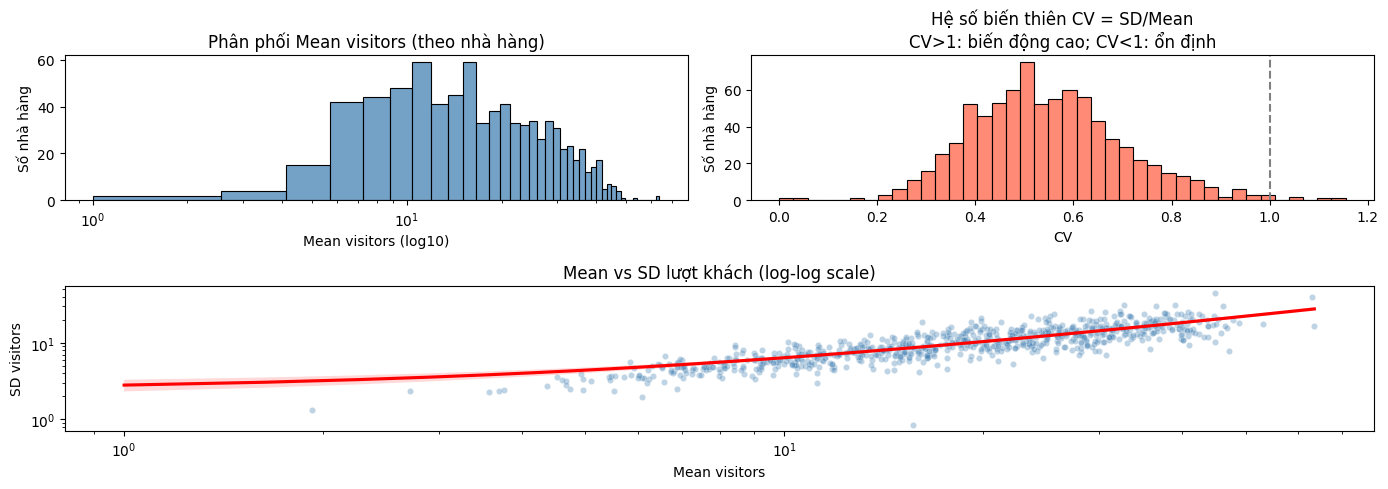

In [14]:
# ==============================
# FIGURE LAYOUT (2x2 grid)
# ==============================
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2)

# ==============================
# (1) Histogram Mean visitors (log scale)
# ==============================
ax1 = fig.add_subplot(gs[0, 0])

sns.histplot(store_stats["mean_v"], bins=40, color="steelblue", ax=ax1)
ax1.set_xscale("log")

ax1.set_title("Phân phối Mean visitors (theo nhà hàng)")
ax1.set_xlabel("Mean visitors (log10)")
ax1.set_ylabel("Số nhà hàng")

# ==============================
# (2) Histogram CV
# ==============================
ax2 = fig.add_subplot(gs[0, 1])

sns.histplot(store_stats["cv"].dropna(), bins=40, color="tomato", ax=ax2)
ax2.axvline(1, linestyle="--", color="gray")

ax2.set_title("Hệ số biến thiên CV = SD/Mean\nCV>1: biến động cao; CV<1: ổn định")
ax2.set_xlabel("CV")
ax2.set_ylabel("Số nhà hàng")

# ==============================
# (3) Mean vs SD (log-log)
# ==============================
ax3 = fig.add_subplot(gs[1, :])  # chiếm cả hàng dưới

sns.scatterplot(
    x="mean_v", y="sd_v",
    data=store_stats,
    alpha=0.35,
    color="steelblue",
    s=20,
    ax=ax3
)

# Fit regression line (linear)
sns.regplot(
    x="mean_v", y="sd_v",
    data=store_stats,
    scatter=False,
    color="red",
    ax=ax3
)

ax3.set_xscale("log")
ax3.set_yscale("log")

ax3.set_title("Mean vs SD lượt khách (log-log scale)")
ax3.set_xlabel("Mean visitors")
ax3.set_ylabel("SD visitors")

# ==============================
# FINALIZE
# ==============================
plt.tight_layout()
plt.show()

**Notes:**
- Most stores have moderate daily traffic, while a small number are much larger.
- Volatility differs substantially across stores.
- This supports a store-level forecasting design rather than a single pooled model.


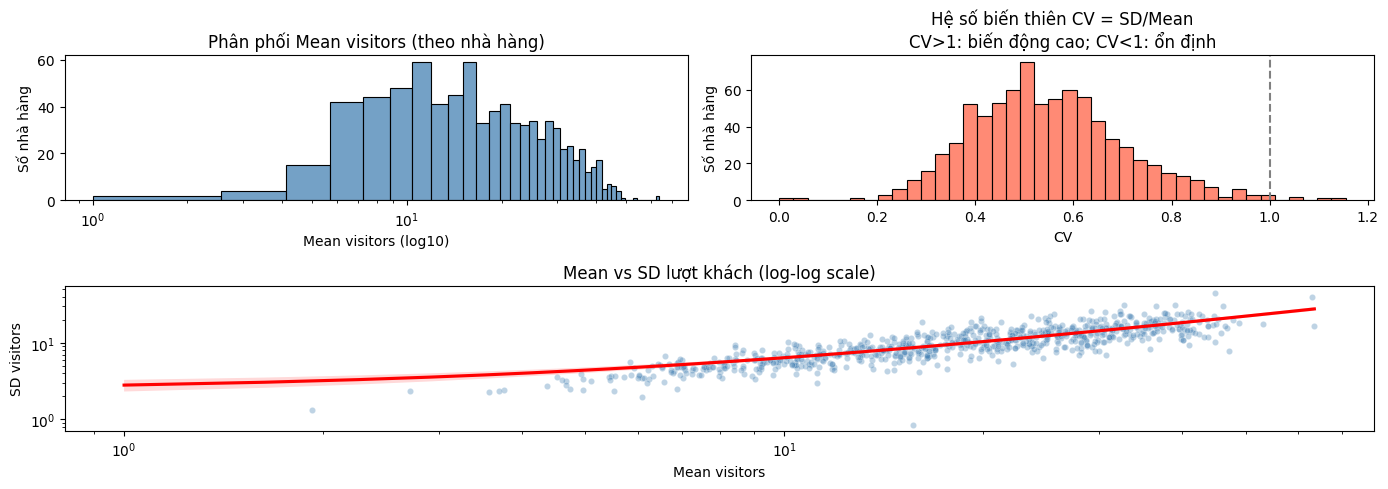

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================
# FIGURE LAYOUT (2x2 grid)
# ==============================
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2)

# ==============================
# (1) Histogram Mean visitors (log scale)
# ==============================
ax1 = fig.add_subplot(gs[0, 0])

sns.histplot(store_stats["mean_v"], bins=40, color="steelblue", ax=ax1)
ax1.set_xscale("log")

ax1.set_title("Phân phối Mean visitors (theo nhà hàng)")
ax1.set_xlabel("Mean visitors (log10)")
ax1.set_ylabel("Số nhà hàng")

# ==============================
# (2) Histogram CV
# ==============================
ax2 = fig.add_subplot(gs[0, 1])

sns.histplot(store_stats["cv"].dropna(), bins=40, color="tomato", ax=ax2)
ax2.axvline(1, linestyle="--", color="gray")

ax2.set_title("Hệ số biến thiên CV = SD/Mean\nCV>1: biến động cao; CV<1: ổn định")
ax2.set_xlabel("CV")
ax2.set_ylabel("Số nhà hàng")

# ==============================
# (3) Mean vs SD (log-log)
# ==============================
ax3 = fig.add_subplot(gs[1, :])  # chiếm cả hàng dưới

sns.scatterplot(
    x="mean_v", y="sd_v",
    data=store_stats,
    alpha=0.35,
    color="steelblue",
    s=20,
    ax=ax3
)

# Fit regression line (linear)
sns.regplot(
    x="mean_v", y="sd_v",
    data=store_stats,
    scatter=False,
    color="red",
    ax=ax3
)

ax3.set_xscale("log")
ax3.set_yscale("log")

ax3.set_title("Mean vs SD lượt khách (log-log scale)")
ax3.set_xlabel("Mean visitors")
ax3.set_ylabel("SD visitors")

# ==============================
# FINALIZE
# ==============================
plt.tight_layout()
plt.show()

**Notes:**
- AIR reservations are sparse in much of 2016.
- Reservation activity becomes much more visible later in the sample.
- AIR reservation coverage alone is not sufficient as the only reservation source.


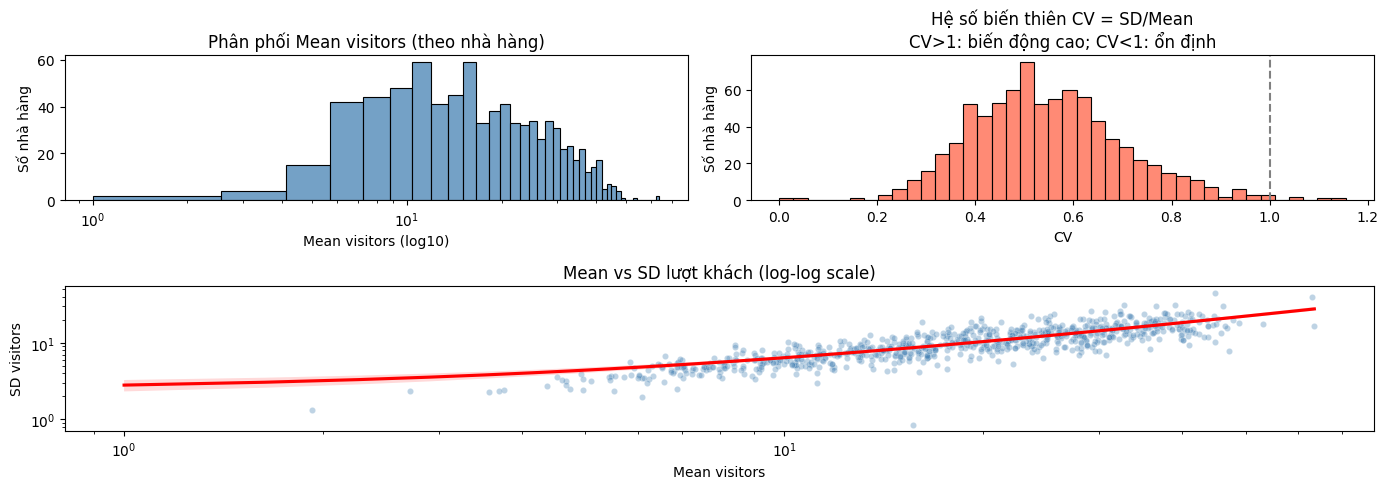

In [16]:

# ==============================
# FIGURE LAYOUT (2x2 grid)
# ==============================
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2)

# ==============================
# (1) Histogram Mean visitors (log scale)
# ==============================
ax1 = fig.add_subplot(gs[0, 0])

sns.histplot(store_stats["mean_v"], bins=40, color="steelblue", ax=ax1)
ax1.set_xscale("log")

ax1.set_title("Phân phối Mean visitors (theo nhà hàng)")
ax1.set_xlabel("Mean visitors (log10)")
ax1.set_ylabel("Số nhà hàng")

# ==============================
# (2) Histogram CV
# ==============================
ax2 = fig.add_subplot(gs[0, 1])

sns.histplot(store_stats["cv"].dropna(), bins=40, color="tomato", ax=ax2)
ax2.axvline(1, linestyle="--", color="gray")

ax2.set_title("Hệ số biến thiên CV = SD/Mean\nCV>1: biến động cao; CV<1: ổn định")
ax2.set_xlabel("CV")
ax2.set_ylabel("Số nhà hàng")

# ==============================
# (3) Mean vs SD (log-log)
# ==============================
ax3 = fig.add_subplot(gs[1, :])  # chiếm cả hàng dưới

sns.scatterplot(
    x="mean_v", y="sd_v",
    data=store_stats,
    alpha=0.35,
    color="steelblue",
    s=20,
    ax=ax3
)

# Fit regression line (linear)
sns.regplot(
    x="mean_v", y="sd_v",
    data=store_stats,
    scatter=False,
    color="red",
    ax=ax3
)

ax3.set_xscale("log")
ax3.set_yscale("log")

ax3.set_title("Mean vs SD lượt khách (log-log scale)")
ax3.set_xlabel("Mean visitors")
ax3.set_ylabel("SD visitors")

# ==============================
# FINALIZE
# ==============================
plt.tight_layout()
plt.show()

**Notes: Comparing AIR and HPG reservations**
- HPG reservation data is more continuous over time.
- AIR and HPG appear to represent different platform coverage patterns.
- Using both sources is more defensible than relying on AIR alone.


In [17]:
import folium
from folium.plugins import MarkerCluster

# ==============================
# 1. Tạo map (center theo dữ liệu)
# ==============================
center_lat = air_store["latitude"].mean()
center_lon = air_store["longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="CartoDB positron")

# ==============================
# 2. Marker cluster (giống markerClusterOptions)
# ==============================
marker_cluster = MarkerCluster().add_to(m)

# ==============================
# 3. Add markers
# ==============================
for _, row in air_store.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=row["air_store_id"],
        tooltip=row["air_genre_name"]
    ).add_to(marker_cluster)

# ==============================
# 4. Scale bar (folium có sẵn)
# ==============================
folium.plugins.MeasureControl(position="bottomleft").add_to(m)

# ==============================
# 5. Hiển thị
# ==============================
m

**Notes:**
- Restaurant locations are concentrated in major urban areas such as Tokyo and Fukuoka.
- Many stores share the same approximate coordinates because the coordinates are area-level.
- Geographic concentration is useful context, but not enough on its own for forecasting.


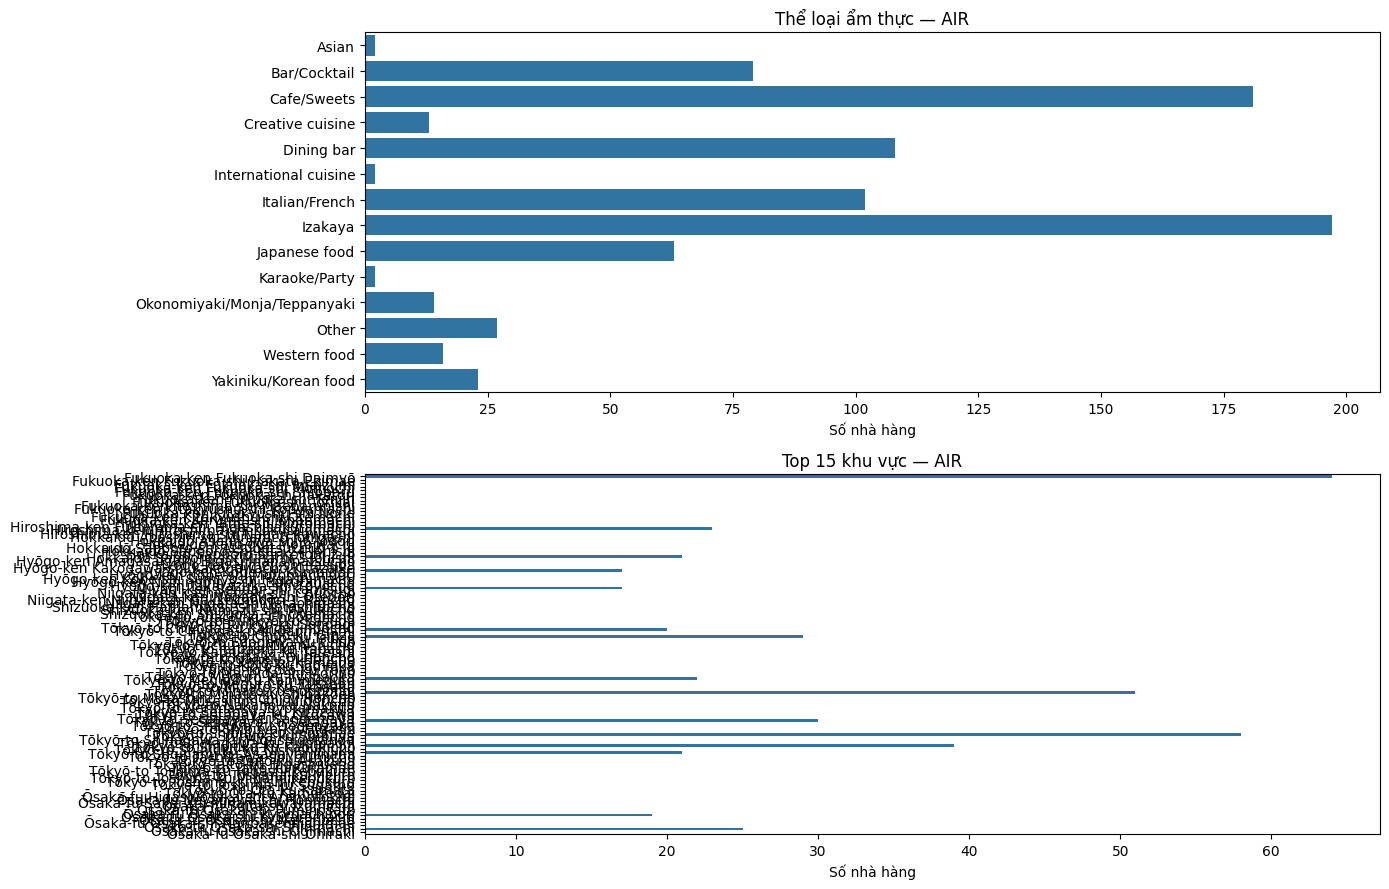

In [18]:

# ==============================
# 1. PREP DATA
# ==============================
# Đếm số lượng theo genre
genre_counts = (
    air_store["air_genre_name"]
    .value_counts()
    .reset_index()
)
genre_counts.columns = ["air_genre_name", "n"]

# Đếm số lượng theo area (top 15)
area_counts = (
    air_store["air_area_name"]
    .value_counts()
    .head(15)
    .reset_index()
)
area_counts.columns = ["air_area_name", "n"]

# ==============================
# 2. FIGURE (2 rows, 1 column)
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ==============================
# (1) GENRE DISTRIBUTION
# ==============================
sns.barplot(
    data=genre_counts.sort_values("n"),
    x="n",
    y="air_genre_name",
    ax=axes[0]
)

axes[0].set_title("Thể loại ẩm thực — AIR")
axes[0].set_xlabel("Số nhà hàng")
axes[0].set_ylabel("")

# ==============================
# (2) TOP 15 AREA
# ==============================
sns.barplot(
    data=area_counts.sort_values("n"),
    x="n",
    y="air_area_name",
    ax=axes[1]
)

axes[1].set_title("Top 15 khu vực — AIR")
axes[1].set_xlabel("Số nhà hàng")
axes[1].set_ylabel("")

# ==============================
# FINALIZE
# ==============================
plt.tight_layout()
plt.show()

**Notes on AIR genre and area distributions:**
- Izakaya and cafe-related categories are especially common.
- Some categories are very small.
- The store mix helps explain why demand patterns differ across restaurants.


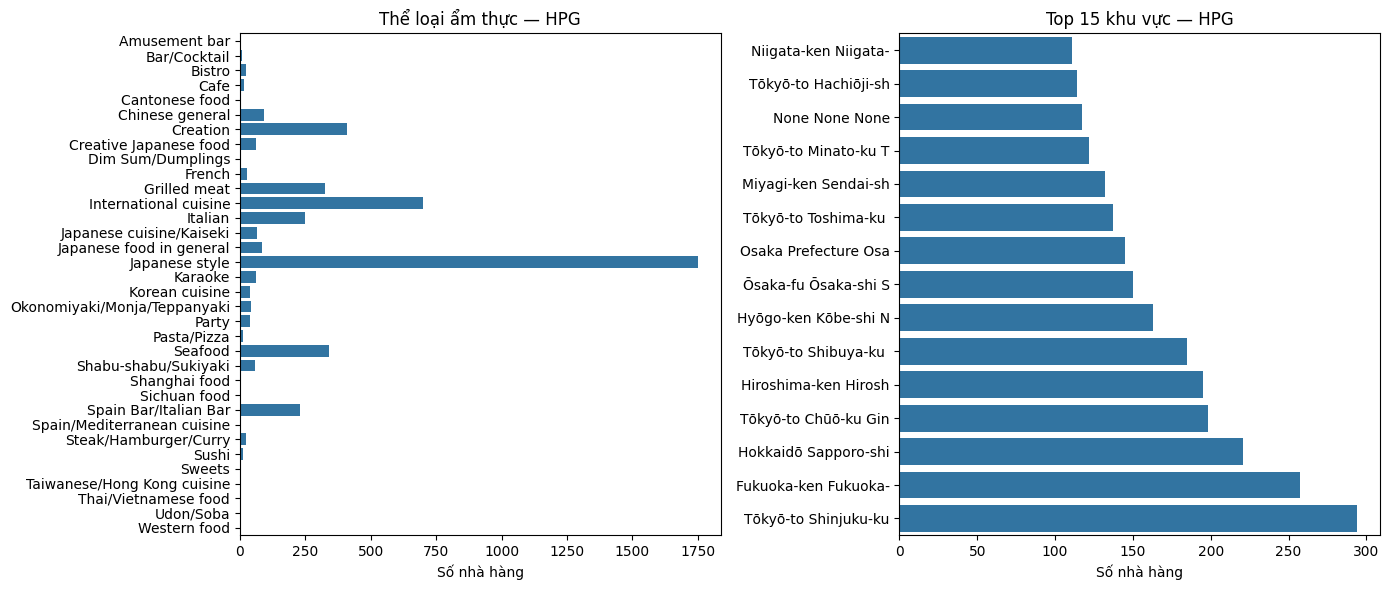

In [19]:


# ==============================
# 1. PREP DATA
# ==============================

# (1) Genre counts
genre_counts = (
    hpg_store["hpg_genre_name"]
    .value_counts()
    .reset_index()
)
genre_counts.columns = ["hpg_genre_name", "n"]

# (2) Area (truncate giống str_sub)
hpg_store["area"] = hpg_store["hpg_area_name"].str[:20]

area_counts = (
    hpg_store["area"]
    .value_counts()
    .head(15)
    .reset_index()
)
area_counts.columns = ["area", "n"]

# ==============================
# 2. FIGURE (1 row, 2 columns)
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==============================
# (1) GENRE DISTRIBUTION
# ==============================
sns.barplot(
    data=genre_counts.sort_values("n"),
    x="n",
    y="hpg_genre_name",
    ax=axes[0]
)

axes[0].set_title("Thể loại ẩm thực — HPG")
axes[0].set_xlabel("Số nhà hàng")
axes[0].set_ylabel("")

# ==============================
# (2) TOP 15 AREA
# ==============================
sns.barplot(
    data=area_counts.sort_values("n"),
    x="n",
    y="area",
    ax=axes[1]
)

axes[1].set_title("Top 15 khu vực — HPG")
axes[1].set_xlabel("Số nhà hàng")
axes[1].set_ylabel("")

# ==============================
# FINALIZE
# ==============================
plt.tight_layout()
plt.show()

**Notes on HPG genre and area distributions:**
- HPG uses a different and often more detailed genre taxonomy.
- Tokyo dominates coverage in HPG.
- The two platforms should not be treated as interchangeable without mapping and interpretation.


C:\Users\asus\AppData\Local\Temp\ipykernel_21244\3207762820.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=foo_hol, x='holiday_str',


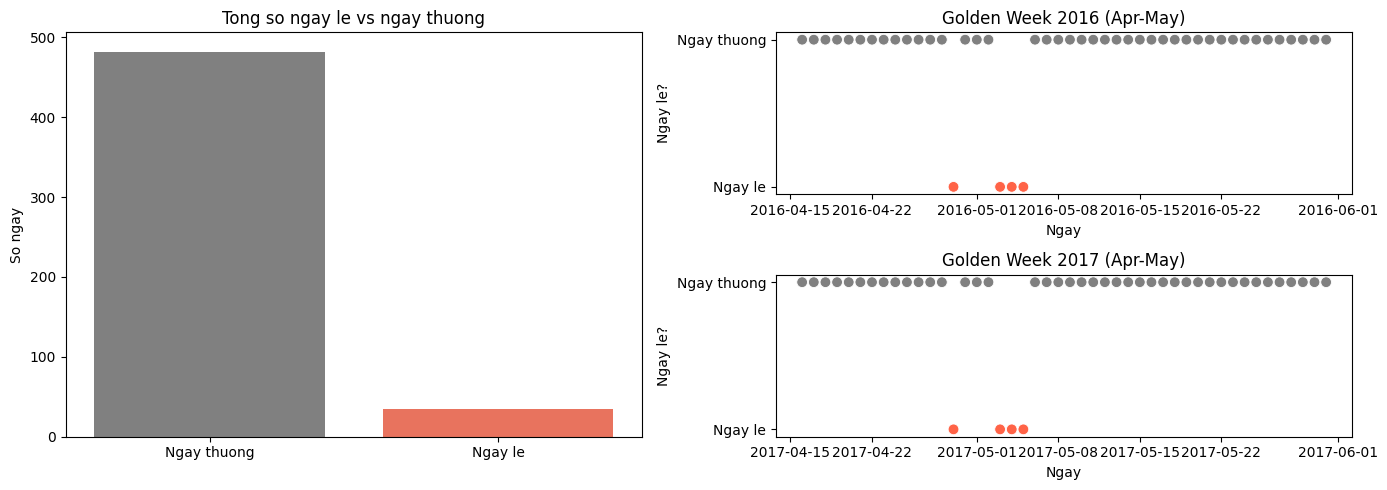

Ty le ngay le: 6.8%


In [20]:

# Chuyển holiday_flg sang string để palette hoạt động đúng
foo_hol = holidays.copy()
foo_hol['wday'] = foo_hol['date'].dt.weekday + 1
foo_hol['holiday_str'] = foo_hol['holiday_flg'].map({False: 'Ngay thuong', True: 'Ngay le'})

pal = {'Ngay thuong': 'grey', 'Ngay le': 'tomato'}

fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(2, 2)

# p1: countplot
ax1 = fig.add_subplot(gs[:, 0])
sns.countplot(data=foo_hol, x='holiday_str',
              order=['Ngay thuong', 'Ngay le'],
              palette=pal, ax=ax1)
ax1.set_title('Tong so ngay le vs ngay thuong')
ax1.set_xlabel('')
ax1.set_ylabel('So ngay')

# p2: 2016
ax2 = fig.add_subplot(gs[0, 1])
df_2016 = foo_hol[(foo_hol['date'] > '2016-04-15') & (foo_hol['date'] < '2016-06-01')]
sns.scatterplot(data=df_2016, x='date', y='holiday_str',
                hue='holiday_str', palette=pal,
                legend=False, s=60, ax=ax2)
ax2.set_title('Golden Week 2016 (Apr-May)')
ax2.set_xlabel('Ngay')
ax2.set_ylabel('Ngay le?')

# p3: 2017
ax3 = fig.add_subplot(gs[1, 1])
df_2017 = foo_hol[(foo_hol['date'] > '2017-04-15') & (foo_hol['date'] < '2017-06-01')]
sns.scatterplot(data=df_2017, x='date', y='holiday_str',
                hue='holiday_str', palette=pal,
                legend=False, s=60, ax=ax3)
ax3.set_title('Golden Week 2017 (Apr-May)')
ax3.set_xlabel('Ngay')
ax3.set_ylabel('Ngay le?')

plt.tight_layout()
plt.show()

holiday_ratio = round(foo_hol['holiday_flg'].mean() * 100, 1)
print(f'Ty le ngay le: {holiday_ratio}%')


**Notes:**
- Holidays represent a small share of days.
- Repeating holiday patterns, including Golden Week, can be encoded consistently.
- Calendar features are therefore a natural input to the final model.


C:\Users\asus\AppData\Local\Temp\ipykernel_21244\3718112370.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  air_visits


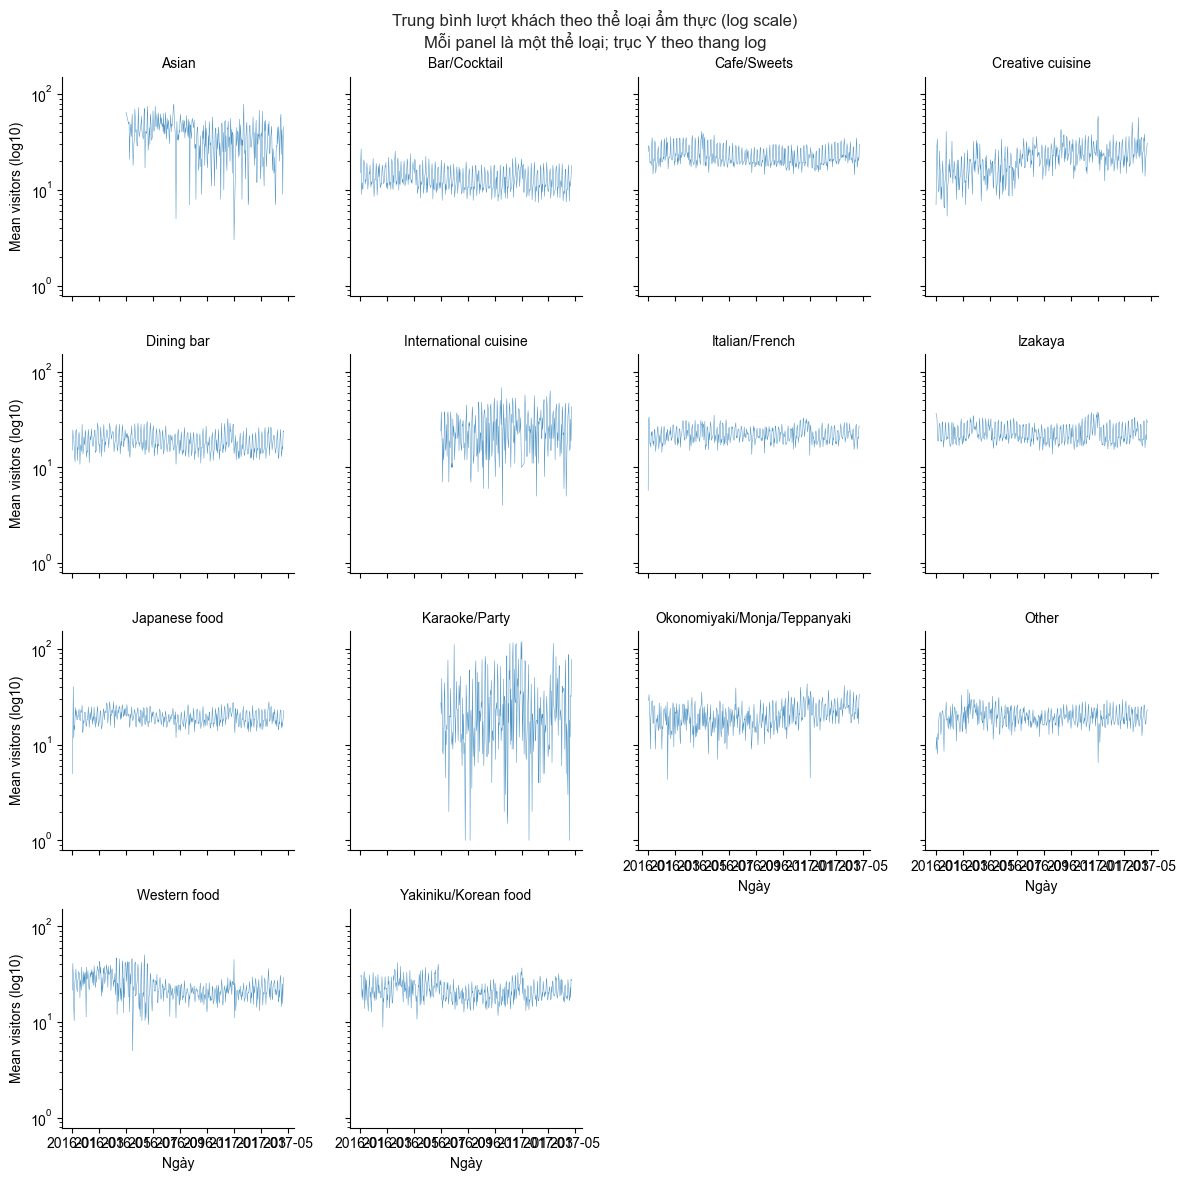

In [21]:


# ===== Join + group + mean =====
df = (
    air_visits
    .merge(air_store, on="air_store_id", how="left")
    .groupby(['visit_date', 'air_genre_name'], as_index=False)['visitors']
    .mean()
    .rename(columns={'visitors': 'mean_v'})
)

# ===== Plot =====
g = sns.FacetGrid(
    df,
    col="air_genre_name",
    col_wrap=4
)

g.map_dataframe(
    sns.lineplot,
    x="visit_date",
    y="mean_v",
    linewidth=0.35,
    alpha=0.8
)

# ===== Log scale =====
for ax in g.axes.flatten():
    ax.set_yscale('log')

# ===== Labels =====
g.set_axis_labels("Ngày", "Mean visitors (log10)")
g.set_titles("{col_name}")

# ===== Style giống theme_minimal =====
sns.set_style("white")

# ===== Title =====
g.fig.suptitle(
    "Trung bình lượt khách theo thể loại ẩm thực (log scale)\n"
    "Mỗi panel là một thể loại; trục Y theo thang log",
    fontsize=12
)

plt.tight_layout()
plt.show()

**Notes:**
- Several cuisine categories show stable but different visitor scales.
- Some categories appear to trend upward over time.
- Genre-level differences reinforce the need for store-aware modeling.


C:\Users\asus\AppData\Local\Temp\ipykernel_21244\1016168579.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  foo_gw


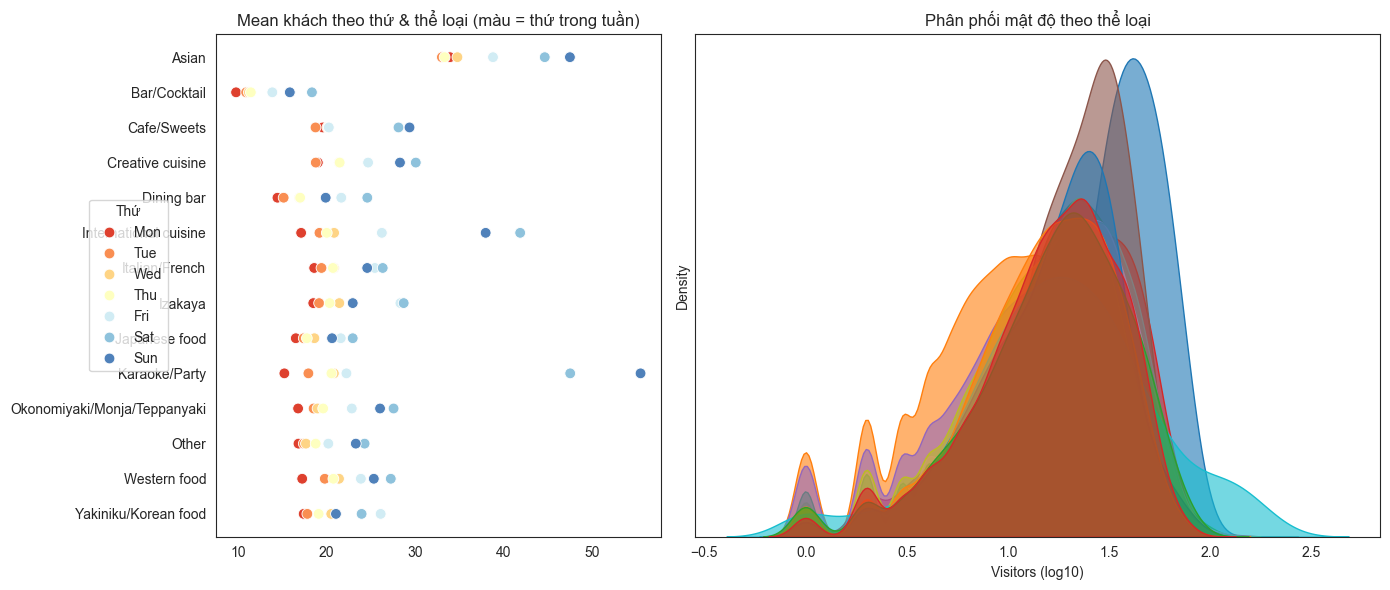

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===== Join =====
foo_gw = air_visits.merge(air_store, on="air_store_id", how="left")

# ===== p1: mean theo wday & genre =====
df_p1 = (
    foo_gw
    .groupby(['wday', 'air_genre_name'], as_index=False)['visitors']
    .mean()
    .rename(columns={'visitors': 'mean_v'})
)

# ===== Layout giống matrix(c(1,1,2,2,2),1,5) =====
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 5)

# ===== p1 (chiếm 2/5 bên trái) =====
ax1 = fig.add_subplot(gs[0, 0:2])

sns.scatterplot(
    data=df_p1,
    x='mean_v',
    y='air_genre_name',
    hue='wday',
    palette='RdYlBu',
    s=60,
    ax=ax1
)

ax1.set_title("Mean khách theo thứ & thể loại (màu = thứ trong tuần)")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.legend(title="Thứ", loc='center left', bbox_to_anchor=(-0.3, 0.5))

# ===== p2: density distribution =====
ax2 = fig.add_subplot(gs[0, 2:5])

# sort để ridge đẹp hơn
genres = sorted(foo_gw['air_genre_name'].dropna().unique())

for i, genre in enumerate(genres):
    subset = foo_gw[foo_gw['air_genre_name'] == genre]['visitors']
    subset = subset[subset > 0]  # tránh lỗi log

    if len(subset) > 1:
        density = sns.kdeplot(
            x=np.log10(subset),
            fill=True,
            alpha=0.6,
            linewidth=1,
            ax=ax2
        )

# chỉnh trục y thành label thể loại (giả ridgeplot)
ax2.set_yticks([])
ax2.set_xlabel("Visitors (log10)")
ax2.set_title("Phân phối mật độ theo thể loại")

# ===== style =====
sns.set_style("white")

plt.tight_layout()
plt.show()

**Notes:**
- Weekend effects differ across cuisine types.
- Entertainment-oriented categories are especially weekend-sensitive.
- Calendar structure is therefore not uniform across stores and genres.


C:\Users\asus\AppData\Local\Temp\ipykernel_21244\1501823316.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  foo_gw


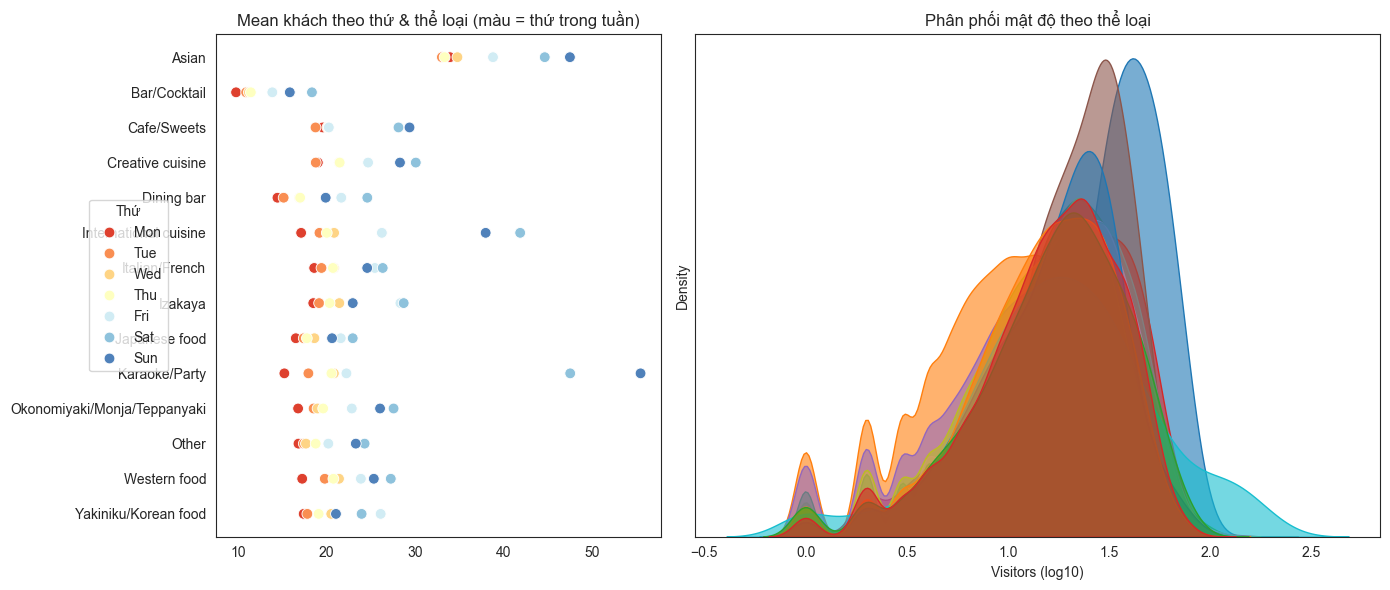

In [23]:

# ===== Join =====
foo_gw = air_visits.merge(air_store, on="air_store_id", how="left")

# ===== p1: mean theo wday & genre =====
df_p1 = (
    foo_gw
    .groupby(['wday', 'air_genre_name'], as_index=False)['visitors']
    .mean()
    .rename(columns={'visitors': 'mean_v'})
)

# ===== Layout giống matrix(c(1,1,2,2,2),1,5) =====
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 5)

# ===== p1 (chiếm 2/5 bên trái) =====
ax1 = fig.add_subplot(gs[0, 0:2])

sns.scatterplot(
    data=df_p1,
    x='mean_v',
    y='air_genre_name',
    hue='wday',
    palette='RdYlBu',
    s=60,
    ax=ax1
)

ax1.set_title("Mean khách theo thứ & thể loại (màu = thứ trong tuần)")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.legend(title="Thứ", loc='center left', bbox_to_anchor=(-0.3, 0.5))

# ===== p2: density distribution =====
ax2 = fig.add_subplot(gs[0, 2:5])

# sort để ridge đẹp hơn
genres = sorted(foo_gw['air_genre_name'].dropna().unique())

for i, genre in enumerate(genres):
    subset = foo_gw[foo_gw['air_genre_name'] == genre]['visitors']
    subset = subset[subset > 0]  # tránh lỗi log

    if len(subset) > 1:
        density = sns.kdeplot(
            x=np.log10(subset),
            fill=True,
            alpha=0.6,
            linewidth=1,
            ax=ax2
        )

# chỉnh trục y thành label thể loại (giả ridgeplot)
ax2.set_yticks([])
ax2.set_xlabel("Visitors (log10)")
ax2.set_title("Phân phối mật độ theo thể loại")

# ===== style =====
sns.set_style("white")

plt.tight_layout()
plt.show()

**Notes:**
- At the aggregate level, holidays alone do not always create a large median shift.
- The effect depends strongly on the day of week.
- Holiday features are more meaningful when interpreted together with weekly seasonality.


In [24]:
# ===== foo_r =====
foo_r = (
    air_reserve
    .assign(visit_date=air_reserve["visit_datetime"].dt.normalize())
    .groupby(["air_store_id", "visit_date"], as_index=False)["reserve_visitors"]
    .sum()
    .rename(columns={"reserve_visitors": "reserve_visitors_air"})
)

# ===== bar_r =====
bar_r = (
    hpg_reserve
    .assign(visit_date=hpg_reserve["visit_datetime"].dt.normalize())
    .groupby(["hpg_store_id", "visit_date"], as_index=False)["reserve_visitors"]
    .sum()
    .rename(columns={"reserve_visitors": "reserve_visitors_hpg"})
    .merge(store_ids, on="hpg_store_id", how="inner")
)

# ===== all_reserve =====
all_reserve = (
    air_visits
    .merge(foo_r, on=["air_store_id", "visit_date"], how="inner")
    .merge(bar_r, on=["air_store_id", "visit_date"], how="inner")
)

# ===== mutate =====
all_reserve["reserve_visitors"] = (
    all_reserve["reserve_visitors_air"] +
    all_reserve["reserve_visitors_hpg"]
)

# ===== output =====
print("So ban ghi co ca du lieu thuc te lan dat ban:", len(all_reserve))


So ban ghi co ca du lieu thuc te lan dat ban: 5889


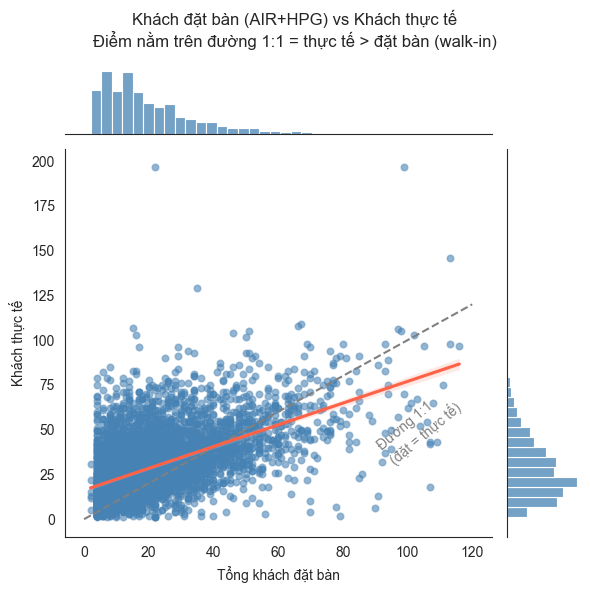

In [25]:


# ===== Filter =====
df = all_reserve[all_reserve['reserve_visitors'] < 120]

# ===== Joint plot (thay cho ggMarginal) =====
g = sns.jointplot(
    data=df,
    x="reserve_visitors",
    y="visitors",
    kind="scatter",
    color="steelblue",
    alpha=0.35,
    height=6,
    marginal_kws=dict(bins=35, fill=True)
)

# ===== Scatter chính =====
g.ax_joint.scatter(
    df['reserve_visitors'],
    df['visitors'],
    color="steelblue",
    alpha=0.35,
    s=20
)

# ===== Đường 1:1 =====
g.ax_joint.plot(
    [0, 120], [0, 120],
    linestyle="--",
    color="grey"
)

# ===== Regression line =====
sns.regplot(
    data=df,
    x="reserve_visitors",
    y="visitors",
    scatter=False,
    ax=g.ax_joint,
    color="tomato"
)

# ===== Annotate =====
g.ax_joint.text(
    90, 30,
    "Đường 1:1\n(đặt = thực tế)",
    color="grey",
    fontsize=10,
    rotation=40
)

# ===== Labels =====
g.ax_joint.set_xlabel("Tổng khách đặt bàn")
g.ax_joint.set_ylabel("Khách thực tế")

g.fig.suptitle(
    "Khách đặt bàn (AIR+HPG) vs Khách thực tế\n"
    "Điểm nằm trên đường 1:1 = thực tế > đặt bàn (walk-in)",
    fontsize=12
)

# ===== Style =====
sns.set_style("white")

plt.tight_layout()
plt.show()

**Notes:**
- Actual visitors are often higher than reservations, which indicates many walk-in customers.
- Some reservation overstatements also exist because of cancellations or no-shows.
- Reservation data is informative, but it is not a complete representation of demand.


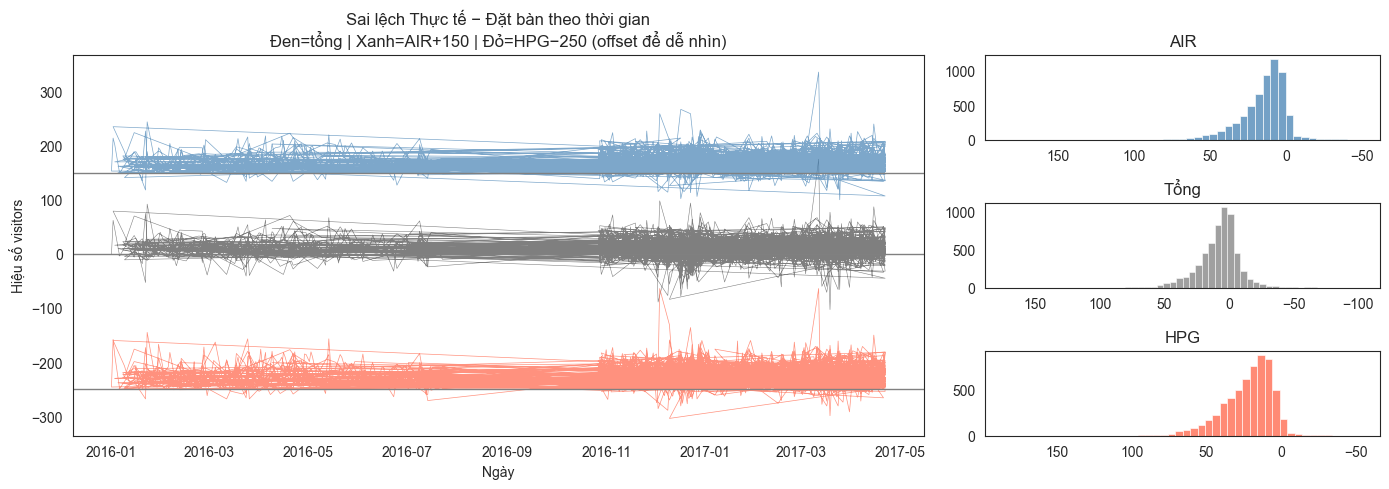

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Tạo các series =====
diff_total = all_reserve['visitors'] - all_reserve['reserve_visitors']
diff_air   = all_reserve['visitors'] - all_reserve['reserve_visitors_air']
diff_hpg   = all_reserve['visitors'] - all_reserve['reserve_visitors_hpg']

# ===== Layout 3x3 giống matrix(...) =====
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(3, 3)

# ===== p4 (chiếm phần lớn) =====
ax4 = fig.add_subplot(gs[:, 0:2])

# line tổng
ax4.plot(all_reserve['visit_date'], diff_total,
         color="black", alpha=0.5, linewidth=0.4)

# line AIR (offset +150)
ax4.plot(all_reserve['visit_date'], diff_air + 150,
         color="steelblue", alpha=0.7, linewidth=0.5)

# line HPG (offset -250)
ax4.plot(all_reserve['visit_date'], diff_hpg - 250,
         color="tomato", alpha=0.7, linewidth=0.5)

# horizontal lines
for y in [150, 0, -250]:
    ax4.axhline(y=y, color="grey", linewidth=1)

ax4.set_title(
    "Sai lệch Thực tế − Đặt bàn theo thời gian\n"
    "Đen=tổng | Xanh=AIR+150 | Đỏ=HPG−250 (offset để dễ nhìn)"
)
ax4.set_xlabel("Ngày")
ax4.set_ylabel("Hiệu số visitors")

# ===== p1: histogram tổng =====
ax1 = fig.add_subplot(gs[1, 2])
sns.histplot(diff_total, binwidth=5, color="grey", ax=ax1)
ax1.set_title("Tổng")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.invert_xaxis()  # giống coord_flip

# ===== p2: histogram AIR =====
ax2 = fig.add_subplot(gs[0, 2])
sns.histplot(diff_air, binwidth=5, color="steelblue", ax=ax2)
ax2.set_title("AIR")
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.invert_xaxis()

# ===== p3: histogram HPG =====
ax3 = fig.add_subplot(gs[2, 2])
sns.histplot(diff_hpg, binwidth=5, color="tomato", ax=ax3)
ax3.set_title("HPG")
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.invert_xaxis()

# ===== Style =====
sns.set_style("white")

plt.tight_layout()
plt.show()

**Notes:**
- The gap between actual visitors and reservations changes over time.
- Reservation signals are useful but incomplete.
- Additional lag and calendar features are needed for a stronger forecasting model.


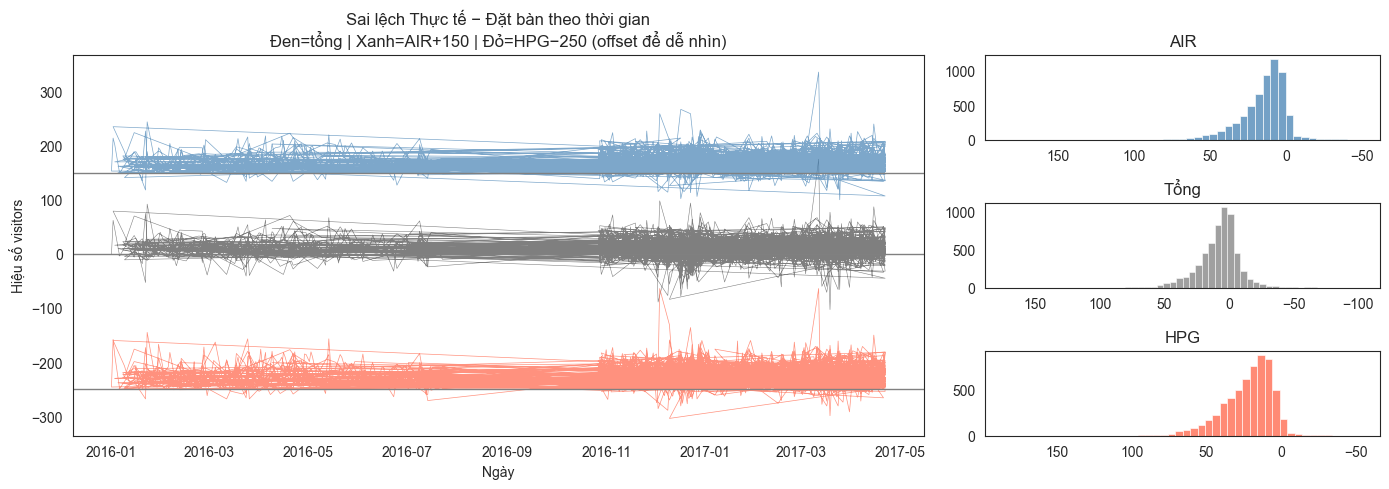

In [27]:

# ===== Tạo các series =====
diff_total = all_reserve['visitors'] - all_reserve['reserve_visitors']
diff_air   = all_reserve['visitors'] - all_reserve['reserve_visitors_air']
diff_hpg   = all_reserve['visitors'] - all_reserve['reserve_visitors_hpg']

# ===== Layout 3x3 giống matrix(...) =====
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(3, 3)

# ===== p4 (chiếm phần lớn) =====
ax4 = fig.add_subplot(gs[:, 0:2])

# line tổng
ax4.plot(all_reserve['visit_date'], diff_total,
         color="black", alpha=0.5, linewidth=0.4)

# line AIR (offset +150)
ax4.plot(all_reserve['visit_date'], diff_air + 150,
         color="steelblue", alpha=0.7, linewidth=0.5)

# line HPG (offset -250)
ax4.plot(all_reserve['visit_date'], diff_hpg - 250,
         color="tomato", alpha=0.7, linewidth=0.5)

# horizontal lines
for y in [150, 0, -250]:
    ax4.axhline(y=y, color="grey", linewidth=1)

ax4.set_title(
    "Sai lệch Thực tế − Đặt bàn theo thời gian\n"
    "Đen=tổng | Xanh=AIR+150 | Đỏ=HPG−250 (offset để dễ nhìn)"
)
ax4.set_xlabel("Ngày")
ax4.set_ylabel("Hiệu số visitors")

# ===== p1: histogram tổng =====
ax1 = fig.add_subplot(gs[1, 2])
sns.histplot(diff_total, binwidth=5, color="grey", ax=ax1)
ax1.set_title("Tổng")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.invert_xaxis()  # giống coord_flip

# ===== p2: histogram AIR =====
ax2 = fig.add_subplot(gs[0, 2])
sns.histplot(diff_air, binwidth=5, color="steelblue", ax=ax2)
ax2.set_title("AIR")
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.invert_xaxis()

# ===== p3: histogram HPG =====
ax3 = fig.add_subplot(gs[2, 2])
sns.histplot(diff_hpg, binwidth=5, color="tomato", ax=ax3)
ax3.set_title("HPG")
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.invert_xaxis()

# ===== Style =====
sns.set_style("white")

plt.tight_layout()
plt.show()

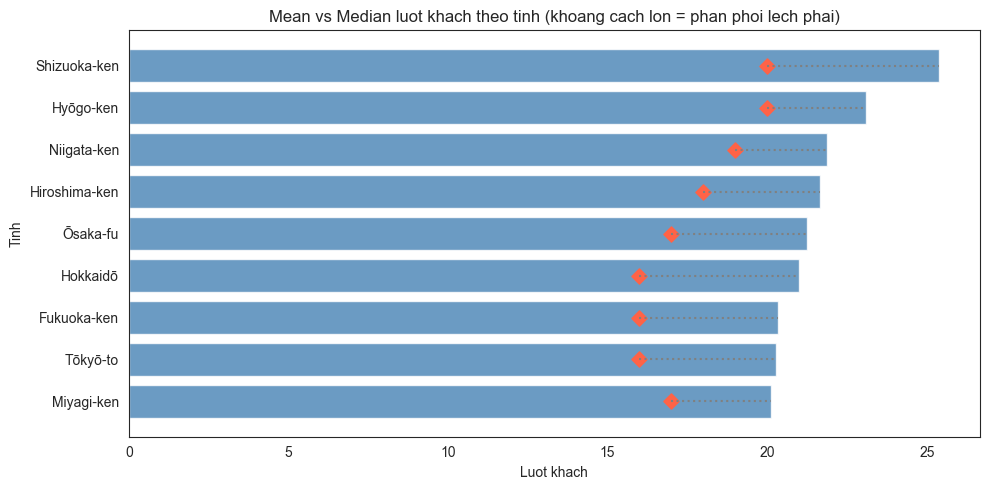

In [28]:
# ===== Join + group =====
df = (
    air_visits
    .merge(air_store, on="air_store_id", how="left")
    .assign(prefecture=lambda x: x["air_area_name"].str.split().str[0])
    .groupby("prefecture", as_index=False)
    .agg(
        mean_v=("visitors", "mean"),
        median_v=("visitors", "median"),
        n=("visitors", "size")
    )
)

# ===== Sort theo mean =====
df = df.sort_values("mean_v")

# ===== Plot =====
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(df["prefecture"], df["mean_v"], color="steelblue", alpha=0.8)
ax.scatter(df["median_v"], df["prefecture"], color="tomato", s=60, marker="D")
ax.hlines(
    y=df["prefecture"],
    xmin=df["median_v"],
    xmax=df["mean_v"],
    colors="grey",
    linestyles="dotted"
)

ax.set_title("Mean vs Median luot khach theo tinh (khoang cach lon = phan phoi lech phai)")
ax.set_xlabel("Luot khach")
ax.set_ylabel("Tinh")

sns.set_style("white")
plt.tight_layout()
plt.show()


**Notes:**
- Tokyo has the highest number of restaurants across both systems.
- Average visitor counts do not differ dramatically across prefectures.
- Geography matters, but it is not the main driver compared with weekly and store-level effects.


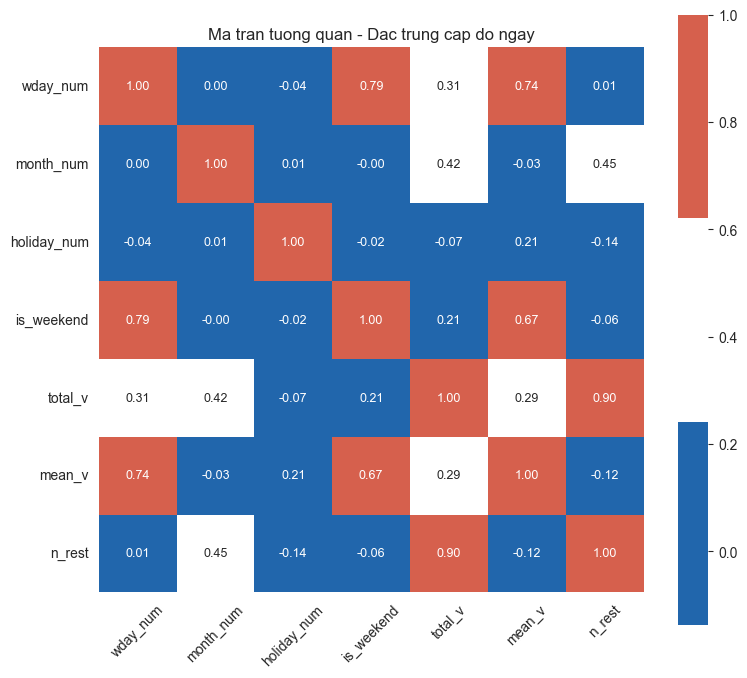

In [29]:
# ===== Tao daily_feat =====
daily_feat = (
    air_visits
    .assign(
        calendar_date=air_visits["visit_date"].dt.strftime("%Y-%m-%d"),
        wday_num=air_visits["visit_date"].dt.dayofweek,
        month_num=air_visits["visit_date"].dt.month
    )
    .merge(holidays, on="calendar_date", how="left")
    .groupby(["visit_date", "wday_num", "month_num", "holiday_flg"], as_index=False)
    .agg(
        total_v=("visitors", "sum"),
        mean_v=("visitors", "mean"),
        n_rest=("air_store_id", "nunique")
    )
)

# ===== mutate them =====
daily_feat["holiday_num"] = daily_feat["holiday_flg"].astype(int)
daily_feat["is_weekend"] = (daily_feat["wday_num"] >= 5).astype(int)

# ===== cor_df =====
cor_df = daily_feat[
    ["wday_num", "month_num", "holiday_num", "is_weekend",
     "total_v", "mean_v", "n_rest"]
].dropna()

# ===== Correlation matrix =====
corr = cor_df.corr()

# ===== Plot heatmap =====
plt.figure(figsize=(8, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(["#2166AC", "white", "#D6604D"], as_cmap=True),
    square=True,
    cbar=True,
    annot_kws={"size": 9}
)

plt.title("Ma tran tuong quan - Dac trung cap do ngay")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

sns.set_style("white")
plt.tight_layout()
plt.show()


**Notes:**
- Weekend-related variables correlate positively with visitor volume.
- Holidays by themselves show weaker linear correlation.
- Some aggregate correlations reflect changing store coverage rather than causal demand effects.


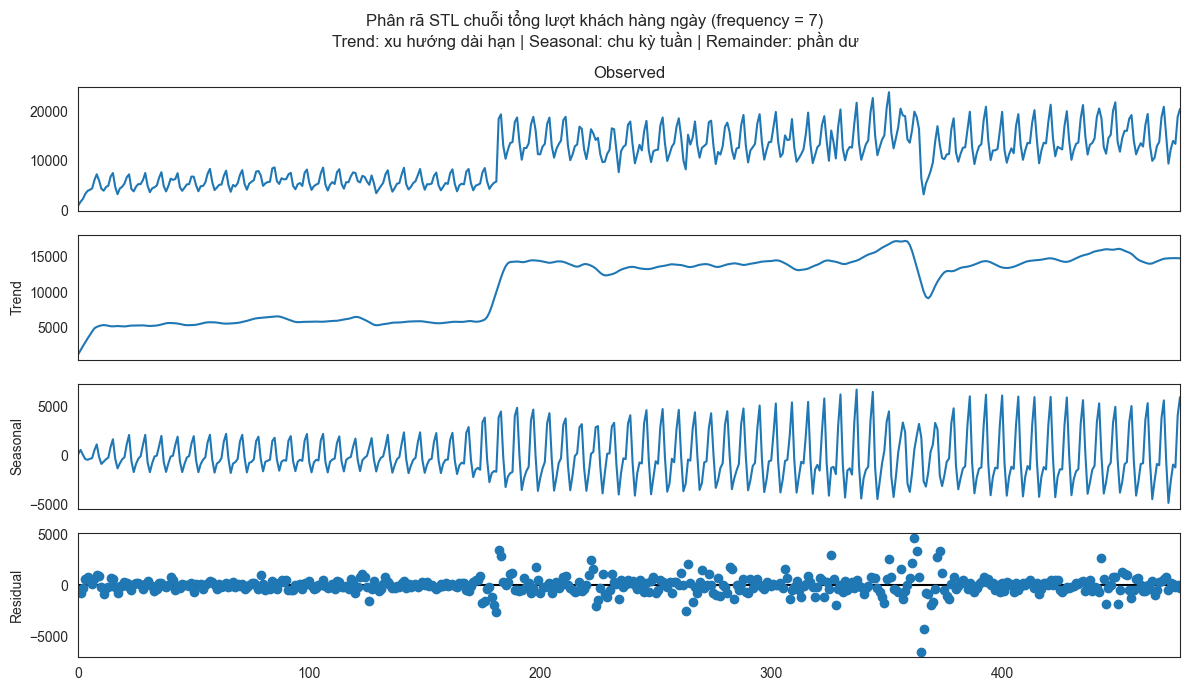

In [30]:

from statsmodels.tsa.seasonal import STL

# ===== daily_total =====
daily_total = (
    air_visits
    .groupby('visit_date', as_index=False)['visitors']
    .sum()
    .rename(columns={'visitors': 'total'})
    .sort_values('visit_date')
)

# ===== tạo time series =====
ts_v = daily_total['total'].values

# ===== STL decomposition (frequency = 7) =====
stl = STL(ts_v, period=7)
stl_fit = stl.fit()

# ===== Plot =====
fig = stl_fit.plot()
fig.set_size_inches(12, 7)

plt.suptitle(
    "Phân rã STL chuỗi tổng lượt khách hàng ngày (frequency = 7)\n"
    "Trend: xu hướng dài hạn | Seasonal: chu kỳ tuần | Remainder: phần dư",
    fontsize=12
)

plt.tight_layout()
plt.show()

**Notes on STL decomposition:**
- The aggregate series has a visible upward trend.
- Weekly seasonality is strong and persistent.
- The remainder is smaller, which suggests that weekly structure explains a large share of variation.


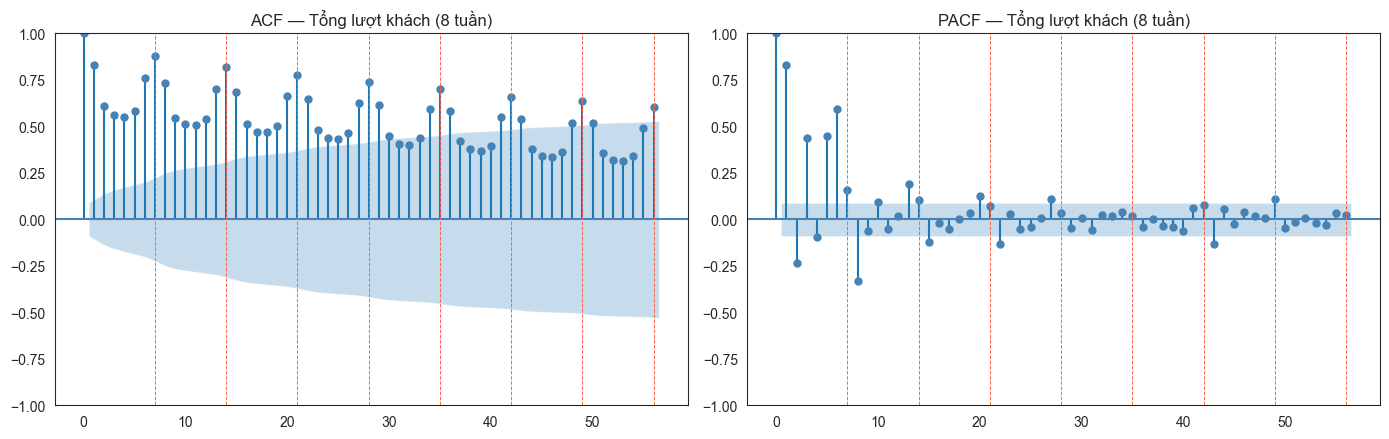

In [31]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ===== Data =====
ts = daily_total['total']

# ===== Plot layout (1 hàng, 2 cột) =====
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ===== ACF =====
plot_acf(ts, lags=56, ax=axes[0], color="steelblue")
axes[0].set_title("ACF — Tổng lượt khách (8 tuần)")

# vertical lines mỗi 7 ngày
for v in range(7, 57, 7):
    axes[0].axvline(x=v, color="tomato", linestyle="--", linewidth=0.7)

# ===== PACF =====
plot_pacf(ts, lags=56, ax=axes[1], color="steelblue", method='ywm')
axes[1].set_title("PACF — Tổng lượt khách (8 tuần)")

# vertical lines mỗi 7 ngày
for v in range(7, 57, 7):
    axes[1].axvline(x=v, color="tomato", linestyle="--", linewidth=0.7)

plt.tight_layout()
plt.show()

**Notes on ACF and PACF:**
- Autocorrelation decays slowly and peaks at multiples of 7.
- This confirms a strong weekly seasonal pattern.
- Seasonal differencing or a weekly seasonal baseline is therefore appropriate.


In [32]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

ts = daily_total['total'].dropna()

# ===== ADF — Chuỗi gốc =====
print("=== KIỂM ĐỊNH ADF — Chuỗi gốc ===")
adf0 = adfuller(ts)

print(f"Test statistic : {adf0[0]:.4f}")
print(f"p-value        : {adf0[1]:.4f}")
print("H0: Chuỗi có nghiệm đơn vị (non-stationary)")

if adf0[1] < 0.05:
    print("Kết luận: Reject H0 → Chuỗi DỪNG")
else:
    print("Kết luận: Fail to reject H0 → Chuỗi KHÔNG DỪNG")


# ===== ADF — differencing bậc 1 =====
print("\n=== KIỂM ĐỊNH ADF — Sau differencing bậc 1 ===")
ts_diff1 = ts.diff().dropna()
adf1 = adfuller(ts_diff1)

print(f"Test statistic : {adf1[0]:.4f}")
print(f"p-value        : {adf1[1]:.4f}")

if adf1[1] < 0.05:
    print("Kết luận: Reject H0 → Chuỗi DỪNG sau differencing d=1")
else:
    print("Kết luận: Cần differencing thêm")


# ===== ADF — seasonal differencing (lag=7) =====
print("\n=== KIỂM ĐỊNH ADF — After seasonal differencing (lag=7) ===")
ts_diff7 = ts.diff(7).dropna()
adf7 = adfuller(ts_diff7)

if adf7[1] < 0.05:
    result = "Dừng sau seasonal differencing"
else:
    result = "Chưa dừng"

print(f"p-value: {adf7[1]:.4f} → {result}")

=== KIỂM ĐỊNH ADF — Chuỗi gốc ===
Test statistic : -1.4904
p-value        : 0.5383
H0: Chuỗi có nghiệm đơn vị (non-stationary)
Kết luận: Fail to reject H0 → Chuỗi KHÔNG DỪNG

=== KIỂM ĐỊNH ADF — Sau differencing bậc 1 ===
Test statistic : -6.7833
p-value        : 0.0000
Kết luận: Reject H0 → Chuỗi DỪNG sau differencing d=1

=== KIỂM ĐỊNH ADF — After seasonal differencing (lag=7) ===
p-value: 0.0000 → Dừng sau seasonal differencing


**Notes on stationarity tests:**
- The original series is not stationary.
- First differencing improves stationarity.
- Seasonal differencing at lag 7 also supports the weekly structure seen in the plots.


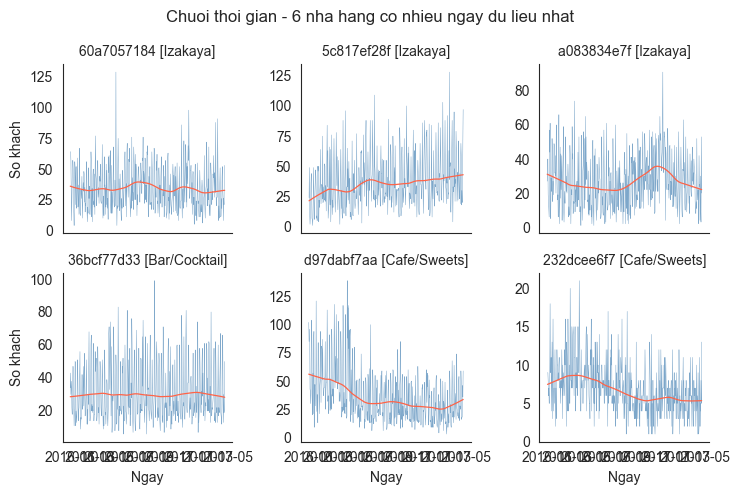

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== top 6 store =====
top6 = (
    air_visits["air_store_id"]
    .value_counts()
    .head(6)
    .index
)

# ===== prepare data =====
df = (
    air_visits[air_visits["air_store_id"].isin(top6)]
    .merge(
        air_store[["air_store_id", "air_genre_name"]],
        on="air_store_id",
        how="left"
    )
)

# ===== tao label =====
df["label"] = (
    df["air_store_id"].str[4:14] +
    " [" + df["air_genre_name"].astype(str) + "]"
)

# ===== Facet plot =====
g = sns.FacetGrid(
    df,
    col="label",
    col_wrap=3,
    sharey=False,
    height=2.5
)

g.map_dataframe(
    sns.lineplot,
    x="visit_date",
    y="visitors",
    color="steelblue",
    linewidth=0.35,
    alpha=0.7
)

# LOESS smooth
from statsmodels.nonparametric.smoothers_lowess import lowess

def add_lowess(data, **kwargs):
    x = data["visit_date"].map(pd.Timestamp.toordinal)
    y = data["visitors"]
    if len(data) > 1:
        smoothed = lowess(y, x, frac=0.25)
        dates = pd.to_datetime(
            [pd.Timestamp.fromordinal(int(v)) for v in smoothed[:, 0]]
        )
        plt.plot(dates, smoothed[:, 1], color="tomato", linewidth=0.9)

g.map_dataframe(add_lowess)

g.set_axis_labels("Ngay", "So khach")
g.set_titles("{col_name}")
g.fig.suptitle(
    "Chuoi thoi gian - 6 nha hang co nhieu ngay du lieu nhat",
    fontsize=12
)
sns.set_style("white")
plt.tight_layout()
plt.show()


**Notes:**
- Stores have very different demand levels, trends, and volatility.
- A single one-size-fits-all series is not appropriate.
- The final project therefore models demand at the store level.


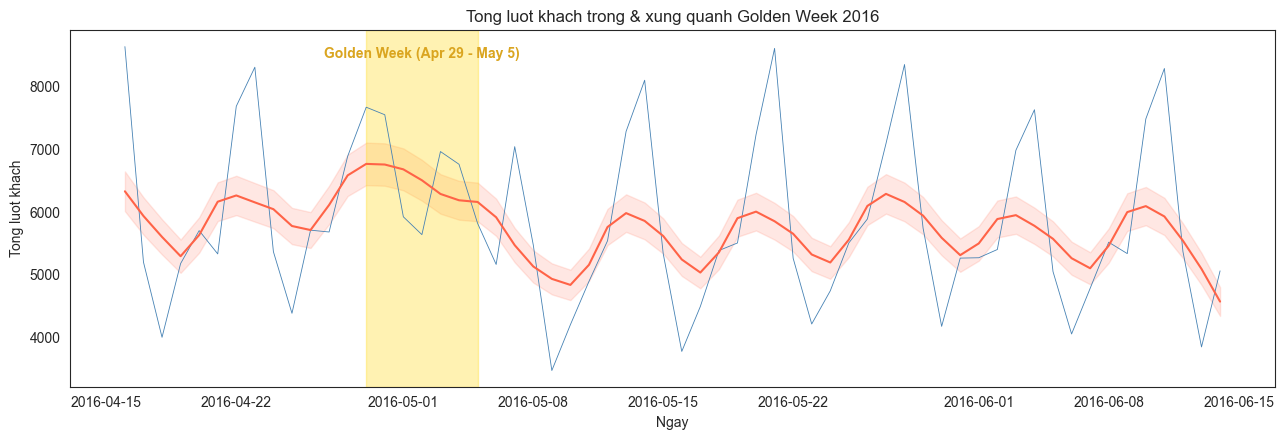

In [34]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# ===== Filter + group =====
df = (
    air_visits[
        (air_visits["visit_date"] > "2016-04-15") &
        (air_visits["visit_date"] < "2016-06-15")
    ]
    .groupby("visit_date", as_index=False)["visitors"]
    .sum()
    .rename(columns={"visitors": "total"})
)

# ===== Plot =====
plt.figure(figsize=(13, 4.5))

plt.plot(df["visit_date"], df["total"], color="steelblue", linewidth=0.6)

# ===== LOESS (LOWESS) =====
x = df["visit_date"].map(pd.Timestamp.toordinal)
y = df["total"]

smoothed = lowess(y, x, frac=1/7)
dates = pd.to_datetime(
    [pd.Timestamp.fromordinal(int(v)) for v in smoothed[:, 0]]
)

plt.plot(dates, smoothed[:, 1], color="tomato")

plt.fill_between(
    dates,
    smoothed[:, 1] * 0.95,
    smoothed[:, 1] * 1.05,
    color="tomato",
    alpha=0.15
)

# ===== Highlight Golden Week =====
plt.axvspan(
    pd.to_datetime("2016-04-29"),
    pd.to_datetime("2016-05-05"),
    color="gold",
    alpha=0.3
)

plt.text(
    pd.to_datetime("2016-05-02"),
    df["total"].max(),
    "Golden Week (Apr 29 - May 5)",
    color="goldenrod",
    fontsize=10,
    fontweight="bold",
    ha="center",
    va="top"
)

plt.title("Tong luot khach trong & xung quanh Golden Week 2016")
plt.xlabel("Ngay")
plt.ylabel("Tong luot khach")
sns.set_style("white")
plt.tight_layout()
plt.show()


**Notes on Golden Week:**
- Golden Week introduces behavior that departs from ordinary weekly seasonality.
- It is important enough to justify a dedicated feature.
- In this project it supports feature design, even though the final holdout ends before the 2017 Golden Week period.


In [35]:
import pandas as pd
from IPython.display import display

findings = pd.DataFrame({
    '#': range(1, 9),
    'Khia canh': [
        'Phan phoi visitors',
        'Chu ky tuan',
        'Mua vu theo thang',
        'Ngay le',
        'Dat ban',
        'Dia ly',
        'Tinh dung',
        'Golden Week'
    ],
    'Phat hien & Ham y': [
        'Lech phai manh; dinh ~20 khach/ngay; goi y bien doi log1p truoc khi mo hinh hoa',
        'Thu 6-CN dong nhat, Thu 2 thap nhat; ACF xac nhan chu ky 7 ngay ro -> frequency=7',
        'Thang 12 va Mar-May cao; khac biet it hon chu ky tuan; can feature month',
        'Tong the khong dang ke; ngay le vao Thu 2-3 tang manh -> can feature holiday x wday',
        'Walk-in nhieu hon dat ban; HPG on dinh hon AIR; ket hop AIR+HPG tot hon',
        'Tokyo va Fukuoka dan dau; prefecture khong anh huong nhieu den mean visitors',
        'Chuoi goc khong dung; chu ky 7 ngay rat ro -> seasonal baseline va ARIMAX deu kha thi',
        'Bien dong bat thuong Apr-May; Golden Week can duoc danh dau rieng trong feature engineering'
    ]
})

print('=== TONG KET CAC PHAT HIEN CHINH TU EDA ===')
display(findings)


=== TONG KET CAC PHAT HIEN CHINH TU EDA ===


,#,Khia canh,Phat hien & Ham y
0,1,Phan phoi visitors,Lech phai manh; dinh ~20 khach/ngay; goi y bie...
1,2,Chu ky tuan,"Thu 6-CN dong nhat, Thu 2 thap nhat; ACF xac n..."
2,3,Mua vu theo thang,Thang 12 va Mar-May cao; khac biet it hon chu ...
3,4,Ngay le,Tong the khong dang ke; ngay le vao Thu 2-3 ta...
4,5,Dat ban,Walk-in nhieu hon dat ban; HPG on dinh hon AIR...
5,6,Dia ly,Tokyo va Fukuoka dan dau; prefecture khong anh...
6,7,Tinh dung,Chuoi goc khong dung; chu ky 7 ngay rat ro -> ...
7,8,Golden Week,Bien dong bat thuong Apr-May; Golden Week can ...


### 7.2 Feature Engineering Recommendations


In [36]:
features = pd.DataFrame({
    'Feature': [
        'log1p(visitors)',
        'wday (thu trong tuan)',
        'month (thang)',
        'is_holiday',
        'holiday x wday (tuong tac)',
        'is_golden_week',
        'lag_7 (visitors 1 tuan truoc)',
        'lag_14 (visitors 2 tuan truoc)',
        'rolling_mean_7',
        'rolling_mean_28',
        'reserve_visitors (dat ban truoc)',
        'diff_hour_to_visit (AIR)',
        'air_genre_name (encoded)',
        'prefecture (encoded)',
        'n_restaurants_in_area'
    ],
    'Muc do uu tien': [
        'Bat buoc','Bat buoc','Quan trong','Quan trong','Quan trong',
        'Bat buoc','Bat buoc','Quan trong','Quan trong','Tuy chon',
        'Quan trong','Tuy chon','Quan trong','Tuy chon','Tuy chon'
    ],
    'Ly do': [
        'On dinh phuong sai; gan phan phoi chuan hon',
        'Chu ky tuan manh - yeu to quan trong nhat',
        'Mua vu thang 12 va Mar-May',
        'Anh huong phi tuyen dac biet vao ngay thuong',
        'Ngay le giua tuan khac ngay le cuoi tuan',
        'Golden Week la bien co lich quan trong -> can danh dau dac biet',
        'Autocorrelation manh tai lag 7',
        'Tang cuong tin hieu tuan',
        'Nam bat xu huong ngan han',
        'Nam bat xu huong trung han',
        'Tin hieu som ve nhu cau',
        'Dat ban sat gio = chi so khac biet AIR vs HPG',
        'The loai anh huong bien do dao dong tuan',
        'Khac biet dia phuong',
        'Muc do canh tranh trong khu vuc'
    ]
})

print('=== GOI Y FEATURE ENGINEERING ===')
display(features)


=== GOI Y FEATURE ENGINEERING ===


,Feature,Muc do uu tien,Ly do
0,log1p(visitors),Bat buoc,On dinh phuong sai; gan phan phoi chuan hon
1,wday (thu trong tuan),Bat buoc,Chu ky tuan manh - yeu to quan trong nhat
2,month (thang),Quan trong,Mua vu thang 12 va Mar-May
3,is_holiday,Quan trong,Anh huong phi tuyen dac biet vao ngay thuong
4,holiday x wday (tuong tac),Quan trong,Ngay le giua tuan khac ngay le cuoi tuan
5,is_golden_week,Bat buoc,Golden Week la bien co lich quan trong -> can ...
6,lag_7 (visitors 1 tuan truoc),Bat buoc,Autocorrelation manh tai lag 7
7,lag_14 (visitors 2 tuan truoc),Quan trong,Tang cuong tin hieu tuan
8,rolling_mean_7,Quan trong,Nam bat xu huong ngan han
9,rolling_mean_28,Tuy chon,Nam bat xu huong trung han


### 7.3 Challenges and Risks to Keep in Mind

Key risks include sparse histories, holiday clustering, unpredictable walk-in traffic, cross-store heterogeneity, reservation coverage gaps, and overfitting on relatively short individual store series.
